# Transformer para Clasificacion Multiclase de Consultas Bancarias

## Informe Tecnico (Comprension)

### Transfer Learning
Técnica de inteligencia artificial en la que se reutiliza un modelo previamente entrenado en una tarea para resolver otra tarea nueva pero relacionada.

* **Punto de partida**: Se toma un modelo que ya sabe procesar información general.
* **Ajuste fino**: Se modifican las capas finales del modelo para adaptarlas al nuevo problema específico.
* **Entrenamiento rápido**: El modelo ajusta sus parámetros usando muchos menos datos nuevos.

### DistilRoBERTa
Modelo de lenguaje basado en la arquitectura Transformer, creado mediante la compresión del modelo RoBERTa-base a `través de un proceso llamado destilación de conocimiento. Este se especializa en analizar texto (NLU - Comprensión del Lenguaje Natural).

* **Tamaño reducido**: Tiene 6 capas en lugar de las 12 del modelo original RoBERTa, lo que reduce sus parámetros en un 35% (alrededor de 82 millones de parámetros frente a los 125 millones del original).
* **Utilidad**: Análisis de sentimiento, Búsqueda semántica y Clasificación de textos.


### Falcon 7B Instruct
Es un modelo de lenguaje grande (LLM) de código abierto con 7 mil millones de parámetros. Es un modelo causal enfocado en descodificadores (decoder-only) especializado en generar texto (NLG - Generación de Lenguaje Natural).

* **Greedy**: en cada paso elige el token con mayor probabilidad (do_sample=False), en vez de muestrear entre opciones.
* **Greedy_xx**: el valor de max_new_tokens, es decir, el límite de tokens nuevos que puede generar; no cuenta el prompt.
* **Cuantizacion**: Es una técnica de compresión que reduce el tamaño de los modelos y acelera su funcionamiento bajando la precisión numérica de sus pesos. Los modelos guardan sus parámetros como números largos de 32 o 16 bits (FP32 o FP16). Implementar dicho metodo ayuda a convertir a formatos más cortos de 8 o 4 bits (INT8 o INT4) usando menos recursos.

### Conceptos de AI

* **Temperatura**: Los modelos de IA eligen las palabras (tokens) una por una calculando probabilidades matemáticas. Este valor llamado temperatura actúa como un multiplicador que modifica esas probabilidades antes de tomar una decisión.

  * **Temperatura baja (0.0 a 0.3)**: El modelo elige siempre la opción más segura y lógica. 
    * **Uso ideal**: Programación, extracción de datos, resúmenes y respuestas factuales.
  * **Temperatura moderada (0.4 a 0.7)**: Ofrece un balance natural entre coherencia y variedad.
    * **Uso ideal**: Conversaciones generales y redacción estándar.
  * **Temperatura alta (0.8 a 1.5+)**: Aplana las probabilidades y permite que aparezcan palabras menos comunes.
    * **Uso ideal**: Narrativa, lluvia de ideas y escritura creativa.

# 1. Preparativos

Usa Python 3.10, 3.11 o 3.12. Ejecuta la celda de instalación una vez desde un kernel de esa versión.

En Linux, la celda crea dos entornos en `~/.venvs/` y kernels independientes para evitar el conflicto entre las versiones CUDA de TensorFlow y PyTorch. 

1. Selecciona **Python (Transformers - TensorFlow GPU)** y vuelve a ejecutar las celdas desde el inicio hasta la clasificación.
2. Selecciona **Python (Transformers - PyTorch GPU)** y ejecuta solo la sección de Falcon; esta carga las predicciones guardadas. 

Cambiar de kernel reinicia el estado en memoria. Ejecuta un modelo GPU a la vez para liberar la memoria de la GPU.

In [7]:
# Ejecutar una vez al abrir el notebook, antes de importar TensorFlow.
# En Linux se crean kernels separados para TensorFlow y PyTorch con GPU.
# En macOS y Windows se instala el conjunto compatible en el entorno actual.
import os
import platform
import subprocess
import sys
from pathlib import Path

# El proyecto se desarrolla con versiones de Python compatibles con TensorFlow 2.16.
if not (sys.version_info >= (3, 10) and sys.version_info < (3, 13)):
    raise RuntimeError("Este proyecto requiere Python 3.10, 3.11 o 3.12.")

system = platform.system()
machine = platform.machine().lower()
print(f"Sistema operativo detectado: {system} ({machine})")

# Librerías comunes necesarias para EDA, visualización, métricas y carga del dataset.
common_requirements = [
    "ipykernel",
    "numpy<2",
    "pandas",
    "matplotlib",
    "seaborn",
    "scipy==1.13.1",
    "scikit-learn==1.7.2",
    "wordcloud",
    "transformers==4.44.2",
    "psutil",
    "truststore>=0.10,<1",
    "tensorflow-datasets==4.9.4",
    "tensorflow-metadata==1.15.0",
]

if system == "Darwin":
    requirements = [
        *common_requirements,
        "tf-keras==2.16.0",
        "torch==2.5.1",
    ]
    # En macOS, la aceleración GPU depende de Apple Silicon (M1/M2/M3).
    # En equipos Intel, TensorFlow puede ejecutarse en CPU pero sin Metal.
    if machine not in {"arm64", "aarch64"}:
        raise RuntimeError(
            "La aceleración GPU de TensorFlow en macOS requiere Apple Silicon (arm64). "
            "En Intel, usa CPU o un entorno con GPU compatible."
        )
    requirements.extend([
        "tensorflow-macos==2.16.2",
        "tensorflow-metal==1.1.0",
    ])

elif system == "Linux":
    if machine not in {"x86_64", "amd64"}:
        raise RuntimeError("Los entornos GPU de TensorFlow 2.16 y PyTorch 2.5.1 requieren Linux x86_64.")

    environments = [
        (
            "transformers-tf-gpu",
            "Python (Transformers - TensorFlow GPU)",
            [*common_requirements, "tf-keras==2.16.0", "tensorflow[and-cuda]==2.16.1"],
        ),
        (
            "transformers-torch-gpu",
            "Python (Transformers - PyTorch GPU)",
            [*common_requirements, "torch==2.5.1", "accelerate>=0.34,<1", "bitsandbytes>=0.45,<1"],
        ),
    ]
    environment_root = Path.home() / ".venvs"
    environment_root.mkdir(parents=True, exist_ok=True)

    for kernel_name, display_name, packages in environments:
        environment_path = environment_root / kernel_name
        environment_python = environment_path / "bin" / "python"
        if not environment_python.exists():
            subprocess.check_call([sys.executable, "-m", "venv", str(environment_path)])
        subprocess.check_call([str(environment_python), "-m", "pip", "install", *packages])
        if kernel_name == "transformers-tf-gpu":
            site_packages = list(environment_path.glob("lib/python*/site-packages"))
            if len(site_packages) != 1:
                raise RuntimeError(f"No se pudo localizar site-packages de TensorFlow en {environment_path}.")
            tensorflow_dir = site_packages[0] / "tensorflow"
            nvidia_dir = site_packages[0] / "nvidia"
            cuda_libraries = sorted(nvidia_dir.glob("*/lib/*.so*"))
            if not cuda_libraries:
                raise RuntimeError(f"No se encontraron bibliotecas CUDA de pip en {nvidia_dir}.")
            for library in cuda_libraries:
                link = tensorflow_dir / library.name
                if link.exists() or link.is_symlink():
                    if link.resolve() != library.resolve():
                        raise RuntimeError(f"Existe un enlace CUDA incompatible: {link}")
                else:
                    link.symlink_to(library)

            ptxas_candidates = list(nvidia_dir.glob("cuda_nvcc/bin/ptxas"))
            if len(ptxas_candidates) != 1:
                raise RuntimeError(f"No se pudo localizar ptxas en {nvidia_dir}.")
            ptxas_link = environment_path / "bin" / "ptxas"
            if ptxas_link.exists() or ptxas_link.is_symlink():
                if ptxas_link.resolve() != ptxas_candidates[0].resolve():
                    raise RuntimeError(f"Existe un enlace ptxas incompatible: {ptxas_link}")
            else:
                ptxas_link.symlink_to(ptxas_candidates[0])
            gpu_check = (
                "import tensorflow as tf; "
                "devices = tf.config.list_physical_devices('GPU'); "
                "print('GPU disponibles:', devices); "
                "assert devices, 'TensorFlow no detectó GPUs; revisa el controlador NVIDIA.'"
            )
            subprocess.check_call([str(environment_python), "-c", gpu_check])
        subprocess.check_call([
            str(environment_python), "-m", "ipykernel", "install", "--user",
            "--name", kernel_name, "--display-name", display_name,
        ])
        print(f"Kernel registrado: {display_name}")

    print("Selecciona el kernel de TensorFlow para DistilRoBERTa y el de PyTorch para Falcon.")

elif system == "Windows":
    requirements = [*common_requirements, "tf-keras==2.16.0", "torch==2.5.1", "accelerate>=0.34,<1", "tensorflow==2.16.1"]
    print("Windows nativo: TensorFlow usa CPU; para GPU NVIDIA se requiere WSL2.")

else:
    raise RuntimeError(f"Sistema operativo no compatible: {system}")

if system != "Linux":
    os.environ["TF_USE_LEGACY_KERAS"] = "1"
    subprocess.check_call([sys.executable, "-m", "pip", "install", *requirements])
    print(f"Dependencias listas para {system}. Reinicia el kernel antes de importar TensorFlow.")

Sistema operativo detectado: Linux (x86_64)



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
2026-10-05 13:02:01.629133: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-10-05 13:02:01.651246: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-10-05 13:02:02.029660: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-10-05 13:02:02.814589: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had n

GPU disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Installed kernelspec transformers-tf-gpu in /home/panchis/.local/share/jupyter/kernels/transformers-tf-gpu
Kernel registrado: Python (Transformers - TensorFlow GPU)



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Installed kernelspec transformers-torch-gpu in /home/panchis/.local/share/jupyter/kernels/transformers-torch-gpu
Kernel registrado: Python (Transformers - PyTorch GPU)
Selecciona el kernel de TensorFlow para DistilRoBERTa y el de PyTorch para Falcon.


# 2. Análisis Exploratorio de Datos (EDA)

El dataset **PolyAI/banking77** contiene 13,083 consultas bancarias breves en inglés, etiquetadas en 77 intenciones (por ejemplo: *activate my card*, *age limit*, *apple pay or google pay*, *atm support*, *automatic top up*, *balance not updated after bank transfer*).

| Partición | Muestras |
|---|---|
| Entrenamiento (train) | 10,003 |
| Prueba (test) | 3,080 |

Fuente: https://huggingface.co/datasets/PolyAI/banking77. Los CSV se descargan del repositorio original de PolyAI, que es la misma fuente que usa el script de carga de Hugging Face.

In [5]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from wordcloud import STOPWORDS as WORDCLOUD_STOPWORDS, WordCloud

sns.set_theme(style="whitegrid")

# Se conservan las particiones oficiales; la concatenación se usa solo para describir el corpus en el EDA.
BASE_URL = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data"
train_df = pd.read_csv(f"{BASE_URL}/train.csv").assign(split="train")
test_df = pd.read_csv(f"{BASE_URL}/test.csv").assign(split="test")
df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Train: {len(train_df):,} | Test: {len(test_df):,} | Total: {len(df):,}")
print(f"Número de categorías: {df['category'].nunique()}")
print(f"Valores nulos:\n{df.isna().sum()}")
print(f"Consultas duplicadas: {df.duplicated(subset='text').sum()}")
df.head()

Train: 10,003 | Test: 3,080 | Total: 13,083
Número de categorías: 77
Valores nulos:
text        0
category    0
split       0
dtype: int64
Consultas duplicadas: 0


,text,category,split
0,I am still waiting on my card?,card_arrival,train
1,What can I do if my card still hasn't arrived ...,card_arrival,train
2,I have been waiting over a week. Is the card s...,card_arrival,train
3,Can I track my card while it is in the process...,card_arrival,train
4,"How do I know if I will get my card, or if it ...",card_arrival,train


## Longitud y número de palabras por consulta

In [6]:
df["char_length"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

df[["text", "char_length", "word_count"]].head(10)

,text,char_length,word_count
0,I am still waiting on my card?,30,7
1,What can I do if my card still hasn't arrived ...,60,13
2,I have been waiting over a week. Is the card s...,58,12
3,Can I track my card while it is in the process...,59,13
4,"How do I know if I will get my card, or if it ...",54,15
5,When did you send me my new card?,33,8
6,Do you have info about the card on delivery?,44,9
7,What do I do if I still have not received my n...,54,13
8,Does the package with my card have tracking?,44,8
9,I ordered my card but it still isn't here,41,9


## Estadísticas descriptivas de longitud y número de palabras

split                 test     train     total
char_length count  3080.00  10003.00  13083.00
            mean     54.23     59.47     58.24
            std      34.66     40.87     39.56
            min      13.00     13.00     13.00
            25%      35.00     36.00     36.00
            50%      45.00     47.00     46.00
            75%      60.00     64.00     63.00
            max     368.00    433.00    433.00
word_count  count  3080.00  10003.00  13083.00
            mean     10.95     11.95     11.71
            std       6.69      7.89      7.64
            min       2.00      2.00      2.00
            25%       7.00      7.00      7.00
            50%       9.00     10.00     10.00
            75%      12.00     13.00     13.00
            max      69.00     79.00     79.00

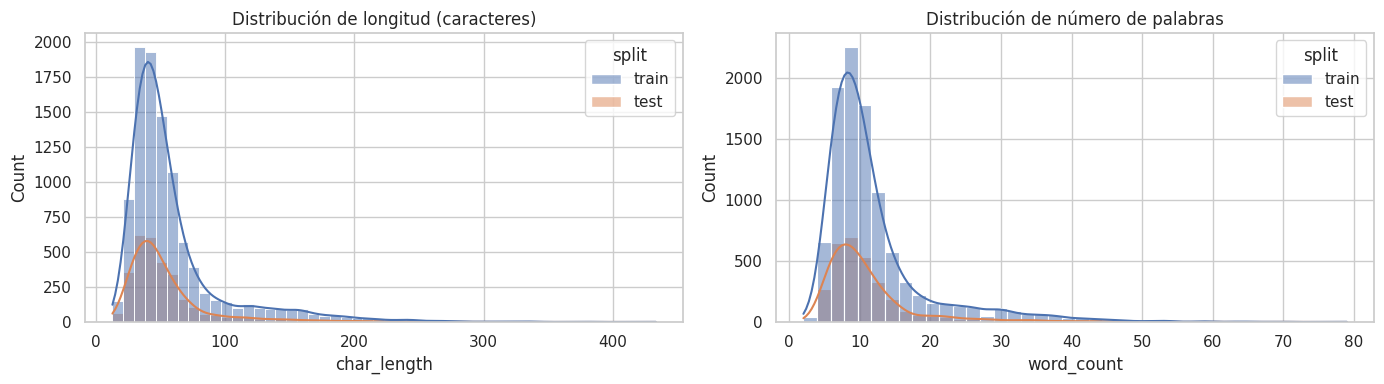

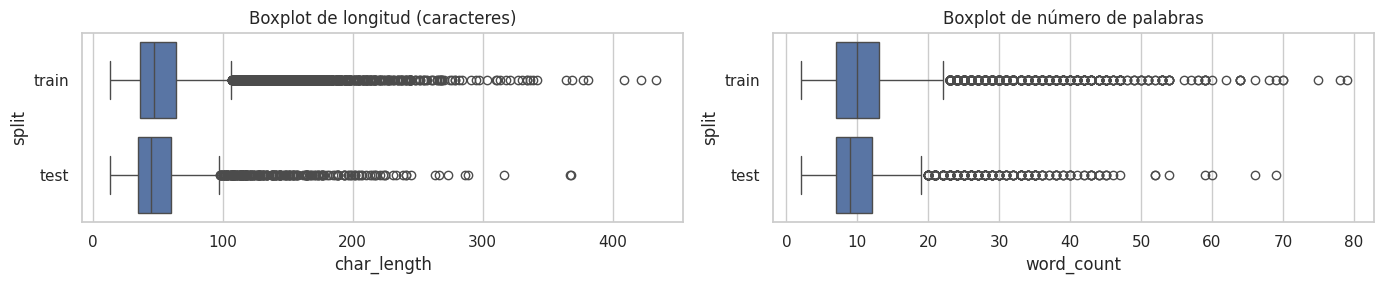

In [7]:
stats = df.groupby("split")[["char_length", "word_count"]].describe().T
stats["total"] = df[["char_length", "word_count"]].describe().T.stack()
display(stats.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=df, x="char_length", hue="split", bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribución de longitud (caracteres)")
sns.histplot(data=df, x="word_count", hue="split", bins=40, kde=True, ax=axes[1])
axes[1].set_title("Distribución de número de palabras")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
sns.boxplot(data=df, x="char_length", y="split", ax=axes[0])
axes[0].set_title("Boxplot de longitud (caracteres)")
sns.boxplot(data=df, x="word_count", y="split", ax=axes[1])
axes[1].set_title("Boxplot de número de palabras")
plt.tight_layout()
plt.show()

## Limpieza básica del texto

1. Conversión a minúsculas.
2. Eliminación de caracteres especiales (números, signos de puntuación, símbolos) y stopwords en inglés.

Se usa la lista de stopwords incluida en `wordcloud`, conservando negaciones (`not`, `no`, `nor`, `cannot`) porque cambian la intención de la consulta (p. ej., *card not working*).

In [8]:
NEGATIONS = {"not", "no", "nor", "cannot"}
# Restos de contracciones tras quitar apóstrofos (i'm -> im, i've -> ive).
CONTRACTION_LEFTOVERS = {"im", "ive", "id", "ill", "youre", "theyre", "thats"}
# Se conservan las negaciones porque cambian la intención; el texto limpio solo se usa para el EDA.
STOPWORDS = (set(WORDCLOUD_STOPWORDS) - NEGATIONS) | CONTRACTION_LEFTOVERS


def clean_text(text: str) -> str:
    text = text.lower()
    text = text.replace("'", "").replace("’", "")
    # Reemplazar, en vez de concatenar, evita unir accidentalmente palabras separadas por puntuación.
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [tok for tok in text.split() if tok not in STOPWORDS and len(tok) > 1]
    return " ".join(tokens)


df["clean_text"] = df["text"].apply(clean_text)
df["clean_word_count"] = df["clean_text"].str.split().str.len()

print(f"Consultas vacías tras la limpieza: {(df['clean_word_count'] == 0).sum()}")
print(f"Promedio de palabras antes: {df['word_count'].mean():.2f} | después: {df['clean_word_count'].mean():.2f}")
df[["text", "clean_text"]].sample(10, random_state=42)

Consultas vacías tras la limpieza: 1
Promedio de palabras antes: 11.71 | después: 5.24


,text,clean_text
353,Please explain the exchange rates.,please explain exchange rates
10210,I got some cash of an ATM earlier but this sho...,got cash atm earlier shows pending app still p...
5361,I just replaced my phone but how do I use my c...,replaced phone use card information
7051,I wasn't able to do a transfer to an account,wasnt able transfer account
3617,I don't recognize a charge on my statement.,dont recognize charge statement
10577,How do I check my security settings to allow c...,check security settings allow contactless pay
6087,What is the average pending time for a transac...,average pending time transaction
2267,is there a limit for top up?,limit top
7712,Why do we need to verify a top-up card?,need verify top card
5576,"I have been doing some online shopping, but wh...",online shopping checking keeps getting decline...


## Las 15 palabras más frecuentes

,palabra,frecuencia
0,card,3578
1,account,1714
2,money,1405
3,transfer,1391
4,top,1381
5,not,1230
6,need,927
7,payment,919
8,cash,884
9,exchange,708


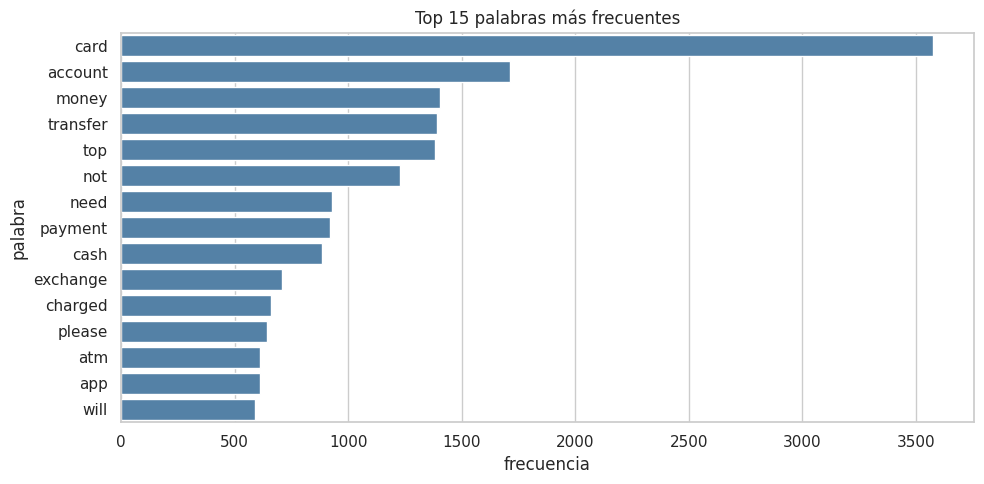

In [9]:
word_counts = Counter(" ".join(df["clean_text"]).split())
top_words = pd.DataFrame(word_counts.most_common(15), columns=["palabra", "frecuencia"])
display(top_words)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_words, x="frecuencia", y="palabra", color="steelblue")
plt.title("Top 15 palabras más frecuentes")
plt.tight_layout()
plt.show()

## Los 10 bigramas y 10 trigramas más frecuentes

,ngrama,frecuencia
0,exchange rate,361
1,new card,286
2,virtual card,282
3,card payment,265
4,cash withdrawal,207
5,money account,153
6,transfer money,151
7,still pending,150
8,please help,147
9,disposable virtual,132


,ngrama,frecuencia
0,disposable virtual card,107
1,long will take,63
2,exchange rate wrong,50
3,transfer money account,40
4,card not working,39
5,charged extra fee,39
6,direct debit payment,39
7,wrong exchange rate,32
8,exchange rate applied,30
9,order new card,29


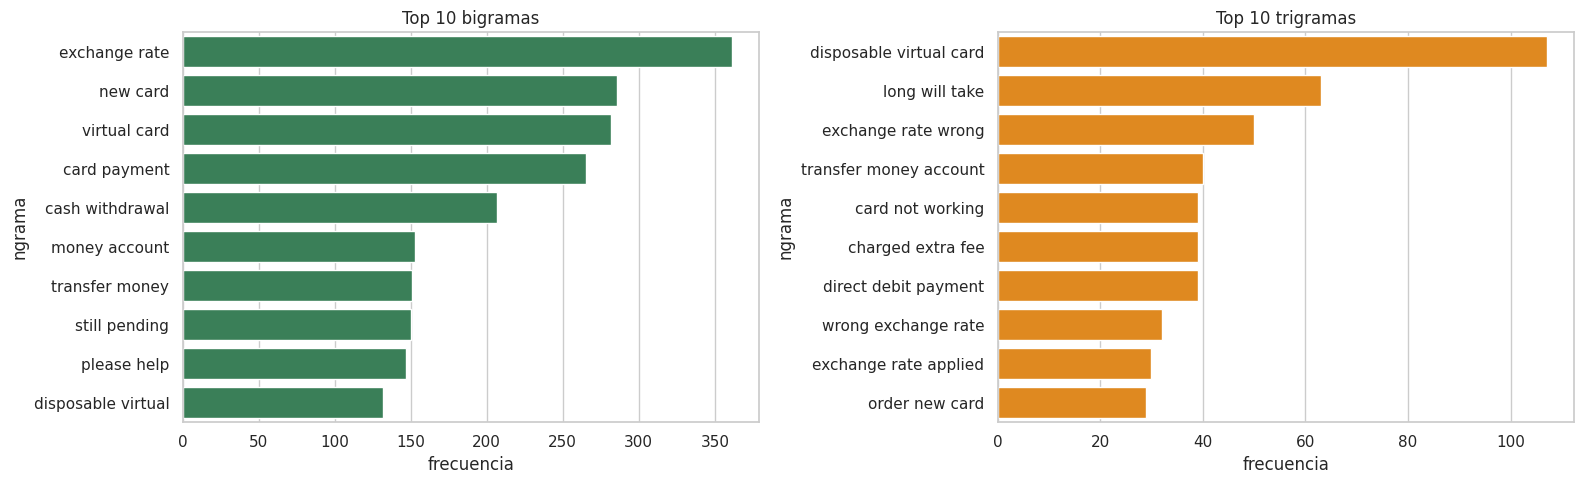

In [10]:
def top_ngrams(texts: pd.Series, n: int, top_k: int = 10) -> pd.DataFrame:
    # Contar ventanas contiguas de n palabras conserva expresiones cuyo sentido depende del contexto local.
    counter = Counter()
    for text in texts:
        tokens = text.split()
        counter.update(" ".join(tokens[i:i + n]) for i in range(len(tokens) - n + 1))
    return pd.DataFrame(counter.most_common(top_k), columns=["ngrama", "frecuencia"])


top_bigrams = top_ngrams(df["clean_text"], n=2)
top_trigrams = top_ngrams(df["clean_text"], n=3)
display(top_bigrams, top_trigrams)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=top_bigrams, x="frecuencia", y="ngrama", color="seagreen", ax=axes[0])
axes[0].set_title("Top 10 bigramas")
sns.barplot(data=top_trigrams, x="frecuencia", y="ngrama", color="darkorange", ax=axes[1])
axes[1].set_title("Top 10 trigramas")
plt.tight_layout()
plt.show()

## Nube de palabras

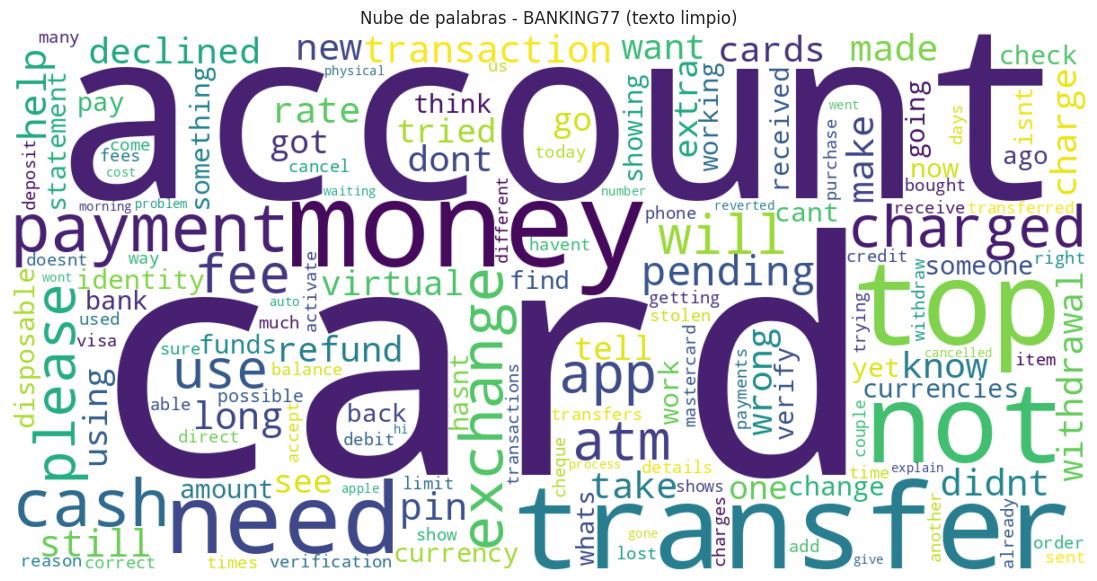

In [11]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis",
    max_words=150,
    random_state=42,
).generate_from_frequencies(word_counts)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras - BANKING77 (texto limpio)")
plt.show()

## Balance de clases

Se considera el *imbalance ratio* (clase mayoritaria / clase minoritaria) y el coeficiente de variación de las frecuencias. Como referencia, un ratio cercano a 1 indica balance perfecto; valores mayores a ~3 suelen requerir técnicas de compensación (pesos de clase, re-muestreo).

[train] min: 35 (contactless_not_working) | max: 187 (card_payment_fee_charged) | media: 129.9 | desv. est.: 32.9 | imbalance ratio: 5.34 | CV: 25.36%
[test] min: 40 (card_payment_fee_charged) | max: 40 (card_payment_fee_charged) | media: 40.0 | desv. est.: 0.0 | imbalance ratio: 1.00 | CV: 0.00%


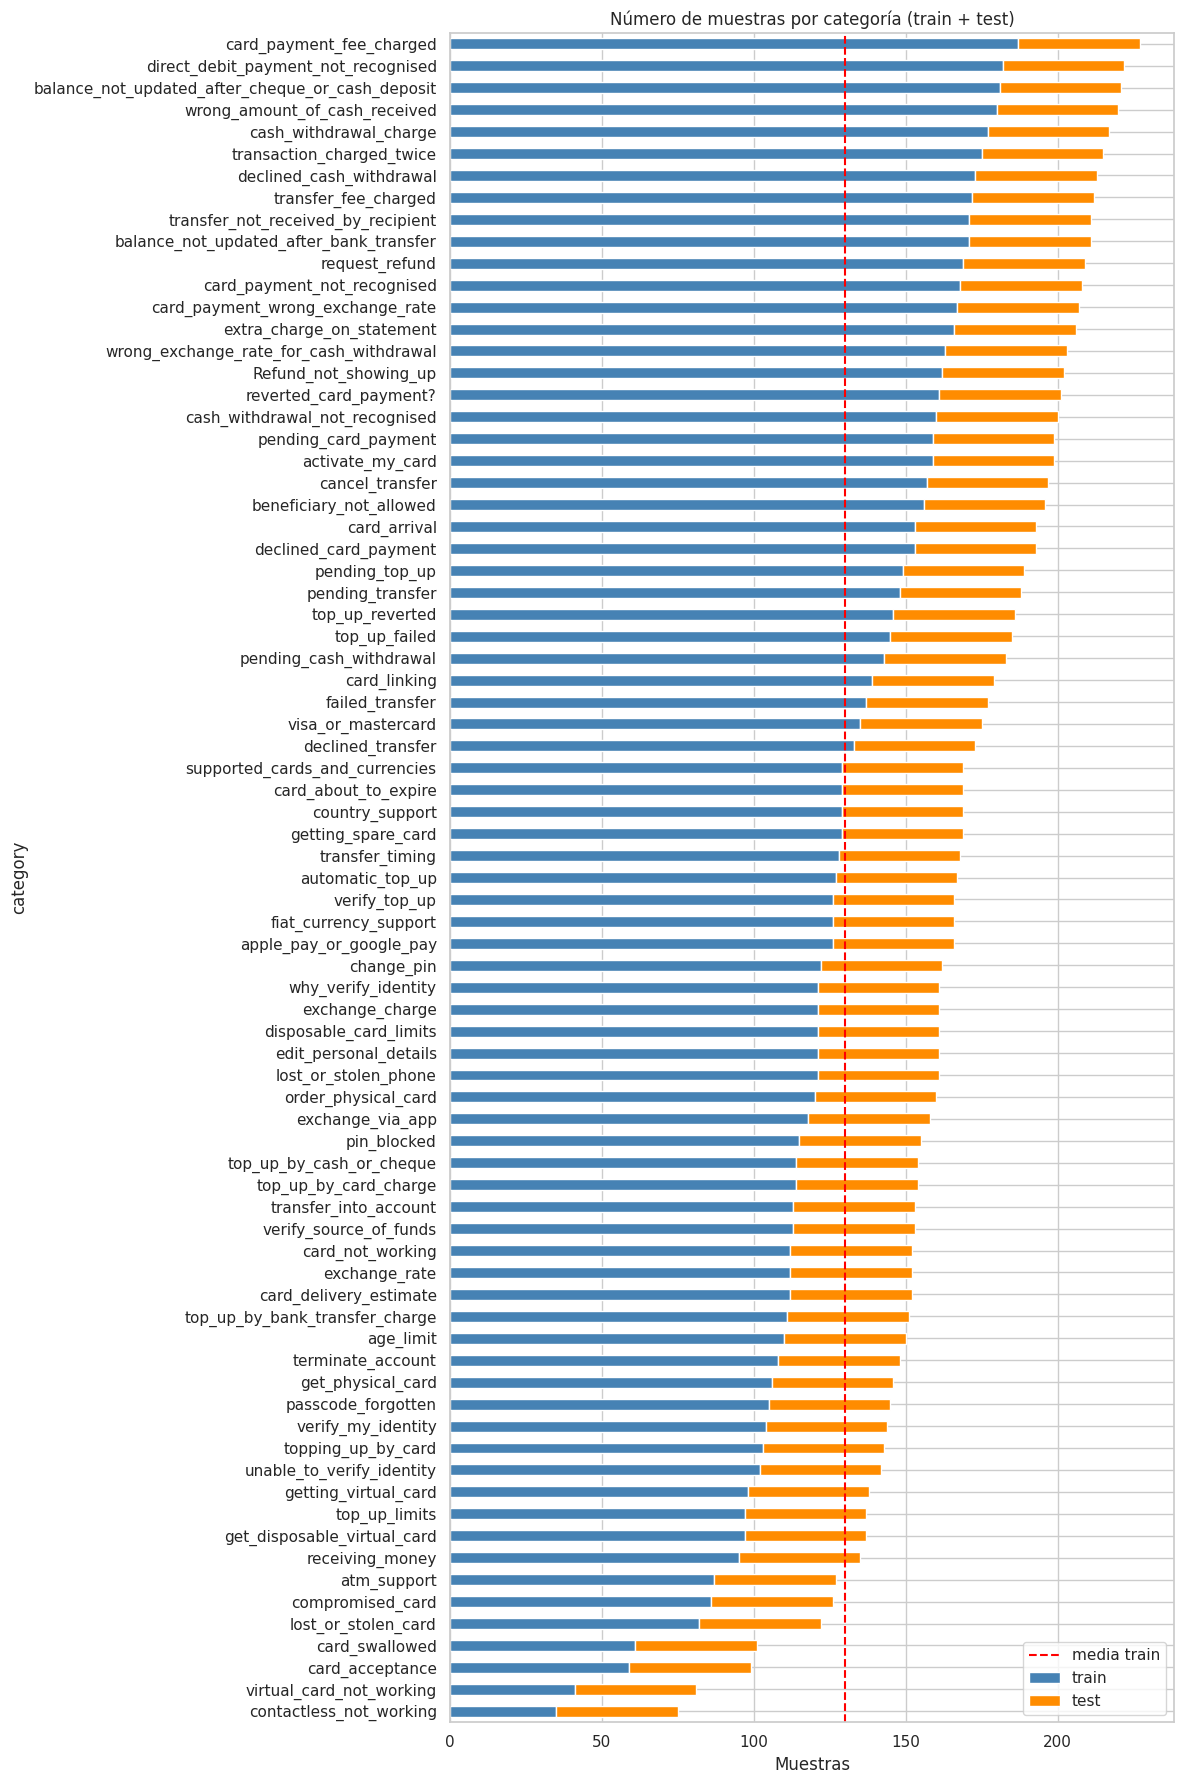

split,test,train
category,,
card_payment_fee_charged,40,187
direct_debit_payment_not_recognised,40,182
balance_not_updated_after_cheque_or_cash_deposit,40,181
wrong_amount_of_cash_received,40,180
cash_withdrawal_charge,40,177


split,test,train
category,,
lost_or_stolen_card,40,82
card_swallowed,40,61
card_acceptance,40,59
virtual_card_not_working,40,41
contactless_not_working,40,35


In [12]:
# Separar por partición permite medir el desbalance de entrenamiento sin confundirlo con test.
class_counts = df.pivot_table(index="category", columns="split", values="text", aggfunc="count")
class_counts = class_counts.sort_values("train", ascending=False)

# El ratio max/min resume la cola larga; el CV (desviación/media) mide dispersión relativa.
for split in ["train", "test"]:
    counts = class_counts[split]
    print(
        f"[{split}] min: {counts.min()} ({counts.idxmin()}) | max: {counts.max()} ({counts.idxmax()}) | "
        f"media: {counts.mean():.1f} | desv. est.: {counts.std():.1f} | "
        f"imbalance ratio: {counts.max() / counts.min():.2f} | CV: {counts.std() / counts.mean():.2%}"
    )

fig, ax = plt.subplots(figsize=(12, 18))
class_counts[["train", "test"]].plot.barh(stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.axvline(class_counts["train"].mean(), color="red", linestyle="--", label="media train")
ax.invert_yaxis()
ax.set_title("Número de muestras por categoría (train + test)")
ax.set_xlabel("Muestras")
ax.legend()
plt.tight_layout()
plt.show()

display(class_counts.head(5), class_counts.tail(5))

## Conclusiones del análisis exploratorio

**Calidad de los datos**
- Se confirman 13,083 consultas (10,003 train / 3,080 test) y 77 categorías, sin valores nulos ni textos duplicados.

**Longitud de las consultas**
- Las consultas son breves: en promedio, ~58 caracteres y ~11.7 palabras (mediana de 46 caracteres y 10 palabras).
- La distribución presenta asimetría positiva marcada: el 75 % de las consultas tiene 13 palabras o menos, aunque existen valores atípicos de hasta 79 palabras (433 caracteres).
- Train y test tienen distribuciones muy parecidas (test ligeramente más corto), por lo que el conjunto de prueba es representativo.
- Implicación para el Transformer: una longitud máxima de secuencia de 64 tokens cubre prácticamente todas las consultas sin truncar información relevante, lo que reduce memoria y tiempo de entrenamiento.

**Vocabulario y limpieza**
- Tras la limpieza, el promedio baja de 11.7 a 5.2 palabras: más de la mitad de cada consulta son stopwords. Solo una consulta queda vacía.
- Las palabras más frecuentes (*card*, *account*, *money*, *transfer*, *top*, *payment*, *cash*, *exchange*, *charged*, *atm*) reflejan el dominio bancario: tarjetas, transferencias, recargas (*top up*) y comisiones.
- La negación *not* aparece entre las 6 palabras más frecuentes, lo que justifica conservarla: distingue intenciones como *card_not_working* o *contactless_not_working*.
- Los bigramas y trigramas (*exchange rate*, *virtual card*, *disposable virtual card*, *card not working*, *charged extra fee*, *wrong exchange rate*) están muy alineados con los nombres de las categorías, por lo que el contexto de varias palabras es clave para separarlas.
- Muchas clases comparten vocabulario (p. ej., *card_payment_fee_charged* vs. *transfer_fee_charged*, *exchange_rate* vs. *card_payment_wrong_exchange_rate*). Esto dificulta la clasificación con bolsas de palabras y favorece modelos contextuales como los Transformers.
- La limpieza agresiva (eliminar stopwords) es útil para el EDA, pero para el fine-tuning conviene usar el texto original con el tokenizador del modelo preentrenado, ya que las palabras funcionales y la puntuación aportan contexto.

**Balance de clases**
- **Test está perfectamente balanceado**: 40 muestras por clase.
- **Train está moderadamente desbalanceado**: de 35 (*contactless_not_working*) a 187 (*card_payment_fee_charged*) muestras, con un *imbalance ratio* de 5.34 y un coeficiente de variación de ~25 %.
- Las clases minoritarias (*contactless_not_working*, *virtual_card_not_working*, *card_acceptance*, *card_swallowed*) tienen menos de la mitad de la media (~130), por lo que es probable que el modelo tenga menor *recall* en ellas.
- Recomendación: usar pesos de clase (`class_weight`) o sobremuestreo de las clases minoritarias y evaluar con métricas macro (F1-macro) además de *accuracy*, aprovechando que el test balanceado permite comparar el rendimiento por clase de forma justa.

# 3. Clasificación con Transformer (DistilRoBERTa)

Se ajusta `distilbert/distilroberta-base` para reconocer las 77 intenciones de BANKING77 con TensorFlow. Se usan los textos originales, no `clean_text`: las negaciones, la puntuación y las palabras funcionales aportan contexto.

**Conexión explícita entre EDA y modelo.** El EDA encontró un *imbalance ratio* de **5.34** en train (35–187 ejemplos por clase), mientras que test tiene exactamente 40 por clase. Por eso `USE_CLASS_WEIGHTS=True` compensa la frecuencia de cada clase usando únicamente el subconjunto de ajuste; el F1-macro y el reporte por clase permiten comprobar si esto mejora las clases minoritarias. El EDA también mostró negaciones frecuentes y expresiones de varias palabras compartidas entre intenciones. En consecuencia, no se eliminan stopwords ni se alimenta `clean_text` al Transformer: se conservan las consultas originales y se revisan las confusiones dirigidas para distinguir conceptos próximos.

El entrenamiento usa el 85 % de **train** y la validación estratificada el 15 % restante. **Test** se reserva para la evaluación final, sin participar en la selección de épocas, pesos de clase ni longitud de secuencia. Ejecutar primero Preparativos, reiniciar el kernel y cargar los datos del EDA.

## Tokenización y preparación

El tokenizer BPE de DistilRoBERTa genera `input_ids` y `attention_mask`. La longitud máxima se fija con el percentil 99 de los tokens del subconjunto de entrenamiento, incluyendo tokens especiales; se informa cuántos textos se truncan en cada partición. El vocabulario y la asignación de etiquetas se conservan para inferencia.

In [ ]:
import os
import sys
from pathlib import Path
import truststore

# Usa las autoridades de confianza del sistema sin desactivar la verificación HTTPS.
# La descarga del tokenizer falló por verificación de certificados HTTPS; se uso el almacén de certificados del sistema, manteniendo la verificación TLS activa.
truststore.inject_into_ssl()

os.environ["TF_USE_LEGACY_KERAS"] = "1"
if "keras" in sys.modules and str(sys.modules["keras"].__version__).startswith("3."):
    raise RuntimeError("Reinicia el kernel y ejecuta Preparativos antes de importar TensorFlow.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tf_keras as keras
from IPython.display import Markdown, display
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification, create_optimizer

SEED = 42
MODEL_NAME = "distilbert/distilroberta-base"
MODEL_REVISION = "fb53ab8802853c8e4fbdbcd0529f21fc6f459b2b"
BATCH_SIZE = 8
EPOCHS = 5
LEARNING_RATE = 2e-5
VALIDATION_FRACTION = 0.15
USE_CLASS_WEIGHTS = True
OUTPUT_DIR = Path("distilroberta_banking77")
keras.utils.set_random_seed(SEED)

assert len(train_df) == 10003 and len(test_df) == 3080
assert train_df[["text", "category"]].notna().all().all()
assert test_df[["text", "category"]].notna().all().all()
class_names = sorted(train_df["category"].unique().tolist())
assert len(class_names) == 77
assert set(test_df["category"]) == set(class_names)
label2id = {name: index for index, name in enumerate(class_names)}
id2label = {index: name for name, index in label2id.items()}

rng = np.random.default_rng(SEED)
fit_indices, validation_indices = [], []
# Muestrear dentro de cada etiqueta conserva su proporción tanto en ajuste como en validación.
for category in class_names:
    indices = np.flatnonzero(train_df["category"].to_numpy() == category)
    rng.shuffle(indices)
    validation_size = max(1, int(round(len(indices) * VALIDATION_FRACTION)))
    validation_indices.extend(indices[:validation_size])
    fit_indices.extend(indices[validation_size:])

fit_df = train_df.iloc[fit_indices].reset_index(drop=True)
validation_df = train_df.iloc[validation_indices].reset_index(drop=True)
evaluation_df = test_df.reset_index(drop=True).copy()
assert set(fit_indices).isdisjoint(validation_indices)
assert len(fit_df) + len(validation_df) == len(train_df)
print(f"Entrenamiento: {len(fit_df)} | Validación: {len(validation_df)} | Test: {len(evaluation_df)}")
print("GPU disponibles:", tf.config.list_physical_devices("GPU"))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, revision=MODEL_REVISION)
# Elegir la longitud solo con train evita usar información de validación o test para configurar el modelo.
fit_token_lengths = np.array([
    len(tokens) for tokens in tokenizer(fit_df["text"].tolist(), truncation=False)["input_ids"]
])
MAX_LENGTH = min(tokenizer.model_max_length, int(np.ceil(np.percentile(fit_token_lengths, 99))))
print(f"Longitud máxima: {MAX_LENGTH} tokens (percentil 99 de entrenamiento)")


def encode_frame(frame):
    # El padding uniforme facilita el batching; truncation limita memoria y se cuantifica aparte abajo.
    return dict(tokenizer(
        frame["text"].tolist(), padding="max_length", truncation=True,
        max_length=MAX_LENGTH, return_tensors="np",
    ))


fit_encoding = encode_frame(fit_df)
validation_encoding = encode_frame(validation_df)
test_encoding = encode_frame(evaluation_df)
fit_labels = fit_df["category"].map(label2id).to_numpy(dtype=np.int32)
validation_labels = validation_df["category"].map(label2id).to_numpy(dtype=np.int32)
test_labels = evaluation_df["category"].map(label2id).to_numpy(dtype=np.int32)

for split_name, frame in [("train", fit_df), ("validation", validation_df), ("test", evaluation_df)]:
    lengths = np.array([len(tokens) for tokens in tokenizer(frame["text"].tolist(), truncation=False)["input_ids"]])
    print(f"{split_name}: {np.mean(lengths > MAX_LENGTH):.2%} de textos truncados")
    if split_name == "test":
        test_token_lengths = lengths

example = tokenizer(fit_df.loc[0, "text"], truncation=True, max_length=MAX_LENGTH)
print("Texto:", fit_df.loc[0, "text"])
print("Tokens:", tokenizer.convert_ids_to_tokens(example["input_ids"]))


def make_dataset(encoding, labels=None, shuffle=False):
    # El dataset sin etiquetas se usa para inferencia; el de ajuste mezcla ejemplos en cada época.
    tensors = encoding if labels is None else (encoding, labels)
    dataset = tf.data.Dataset.from_tensor_slices(tensors)
    if shuffle:
        dataset = dataset.shuffle(len(labels), seed=SEED, reshuffle_each_iteration=True)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


fit_dataset = make_dataset(fit_encoding, fit_labels, shuffle=True)
validation_dataset = make_dataset(validation_encoding, validation_labels)
test_dataset = make_dataset(test_encoding)

Entrenamiento: 8505 | Validación: 1498 | Test: 3080
GPU disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Longitud máxima: 51 tokens (percentil 99 de entrenamiento)


2026-10-05 12:49:39.266782: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-10-05 12:49:39.283934: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-10-05 12:49:39.284940: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

train: 0.95% de textos truncados
validation: 1.07% de textos truncados
test: 0.55% de textos truncados
Texto: No refund showing in my statement.
Tokens: ['<s>', 'No', 'Ġrefund', 'Ġshowing', 'Ġin', 'Ġmy', 'Ġstatement', '.', '</s>']


2026-10-05 12:49:39.727785: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-10-05 12:49:39.729422: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-10-05 12:49:39.730130: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

## Fine-tuning del modelo preentrenado

Se sustituye la cabeza de preentrenamiento por un clasificador de 77 etiquetas y se ajustan **todas las capas**. Es normal recibir un aviso de pesos nuevos en el clasificador: estos se aprenden durante el fine-tuning.

Configuración inicial: batch de 8, hasta 5 épocas, AdamW con tasa de aprendizaje `2e-5`, warmup del 10 %, decaimiento de pesos y clipping de gradientes. Los pesos de clase se calculan solo con el subconjunto de entrenamiento. La parada temprana restaura la época con menor pérdida de validación (sin ponderar). Estos hiperparámetros son un punto de partida, no una garantía de rendimiento.

Esta celda descarga los pesos de TensorFlow del modelo (~487 MB) y puede tardar considerablemente en CPU. Si falta memoria, reducir `BATCH_SIZE`; no modificar test para elegir los hiperparámetros.

All PyTorch model weights were used when initializing TFRobertaForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5
Cause: for/else statement not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: for/else statement not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
1064/1064 [==============================] - 53s 33ms/step - loss: 3.1625 - accuracy: 0.4178 - val_loss: 1.4141 - val_accuracy: 0.8091
Epoch 2/5
1064/1064 [==============================] - 32s 30ms/step - loss: 1.0398 - accuracy: 0.8556 - val_loss: 0.5639 - val_accuracy: 0.8905
Epoch 3/5
1064/1064 [==============================] - 33s 31ms/step - loss: 0.4606 - accuracy: 0.9193 - val_loss: 0.3626 - val_accuracy: 0.9126
Epoch 4/5
1064/1064 [==============================] - 31s 29ms/step - loss: 0.2631 - accuracy: 0.9480 - val_loss: 0.3169 - val_accuracy: 0.9152
Epoch 5/5
1064/1064 [==============================] - 32s 30ms/step - loss: 0.1843 - accuracy: 0.9618 - val_loss: 0.3107 - val_accuracy: 0.9179

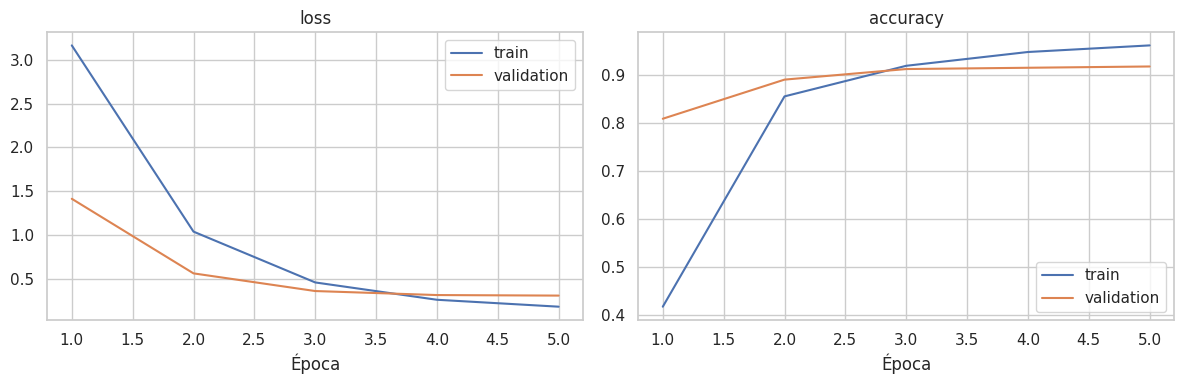

In [15]:
import os
from huggingface_hub import constants as hub_constants

# Xet es el sistema que utiliza Hugging Face para almacenar y descargar archivos grandes, como los pesos de los modelos. Trabaja con bloques de datos para evitar transferencias duplicadas y acelerar las descargas.
# Cuando está instalado hf_xet, Hugging Face puede usarlo automáticamente.

# En caso de que la ruta de Xet falle con 403 Forbidden y la descarga HTTP convencional funcione, se puede desactivar Xet usando:

os.environ["HF_HUB_DISABLE_XET"] = "1"
hub_constants.HF_HUB_DISABLE_XET = True

model = TFAutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, revision=MODEL_REVISION, num_labels=len(class_names),
    id2label=id2label, label2id=label2id,
)
model.trainable = True
steps_per_epoch = int(np.ceil(len(fit_df) / BATCH_SIZE))
training_steps = steps_per_epoch * EPOCHS
optimizer, learning_rate_schedule = create_optimizer(
    init_lr=LEARNING_RATE, num_train_steps=training_steps,
    num_warmup_steps=int(training_steps * 0.1), weight_decay_rate=0.01,
    adam_global_clipnorm=1.0,
)
model.compile(
    optimizer=optimizer,
    # El modelo entrega logits sin normalizar; from_logits=True evita aplicar softmax dos veces.
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)
# Inversa de frecuencia normalizada: el peso medio por clase queda aproximadamente en 1.
# Se calcula en el subconjunto de ajuste para no incorporar información de validación o test.
fit_support = np.bincount(fit_labels, minlength=len(class_names))
class_weights = {
    index: float(len(fit_labels) / (len(class_names) * support))
    for index, support in enumerate(fit_support)
}
training_history = model.fit(
    fit_dataset, validation_data=validation_dataset, epochs=EPOCHS,
    class_weight=class_weights if USE_CLASS_WEIGHTS else None,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
        keras.callbacks.TerminateOnNaN(),
    ],
)
assert np.isfinite(training_history.history["val_loss"]).all(), "Pérdida no finita: revisar entrenamiento."
best_epoch = int(np.argmin(training_history.history["val_loss"]) + 1)
print(f"Mejor época por pérdida de validación: {best_epoch}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
model.save_pretrained(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))
import json
(OUTPUT_DIR / "training_config.json").write_text(json.dumps({
    "model": MODEL_NAME, "revision": MODEL_REVISION, "seed": SEED,
    "max_length": MAX_LENGTH, "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE, "best_epoch": best_epoch,
    "class_weights": USE_CLASS_WEIGHTS,
}, indent=2), encoding="utf-8")

history_df = pd.DataFrame(training_history.history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for metric_name, axis in zip(["loss", "accuracy"], axes):
    axis.plot(history_df.index + 1, history_df[metric_name], label="train")
    axis.plot(history_df.index + 1, history_df[f"val_{metric_name}"], label="validation")
    axis.set(title=metric_name, xlabel="Época")
    axis.legend()
plt.tight_layout()
plt.show()

## Evaluación: accuracy, matriz de confusión y reporte de métricas

Se evalúa una vez en las 3,080 consultas de test, manteniendo el orden original. La matriz tiene **clases reales en las filas** y **predicciones en las columnas**; se muestran los conteos y la normalización por fila (recall por clase en la diagonal). El reporte incluye precision, recall, F1 y support de las 77 clases, además de promedios macro y ponderados. `zero_division=0` asigna cero si no hay predicciones para una clase.

385/385 [==============================] - 4s 6ms/step
Accuracy: 0.9218 (92.18%)
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up     0.9756    1.0000    0.9877        40
                                activate_my_card     1.0000    0.9750    0.9873        40
                                       age_limit     1.0000    1.0000    1.0000        40
                         apple_pay_or_google_pay     1.0000    1.0000    1.0000        40
                                     atm_support     0.9524    1.0000    0.9756        40
                                automatic_top_up     1.0000    0.9000    0.9474        40
         balance_not_updated_after_bank_transfer     0.7561    0.7750    0.7654        40
balance_not_updated_after_cheque_or_cash_deposit     1.0000    0.9500    0.9744        40
                         beneficiary_not_allowed     0.9231    0.9000    0.9114        40
                  

,precision,recall,f1-score,support
macro avg,0.925014,0.921753,0.921666,3080.0
weighted avg,0.925014,0.921753,0.921666,3080.0


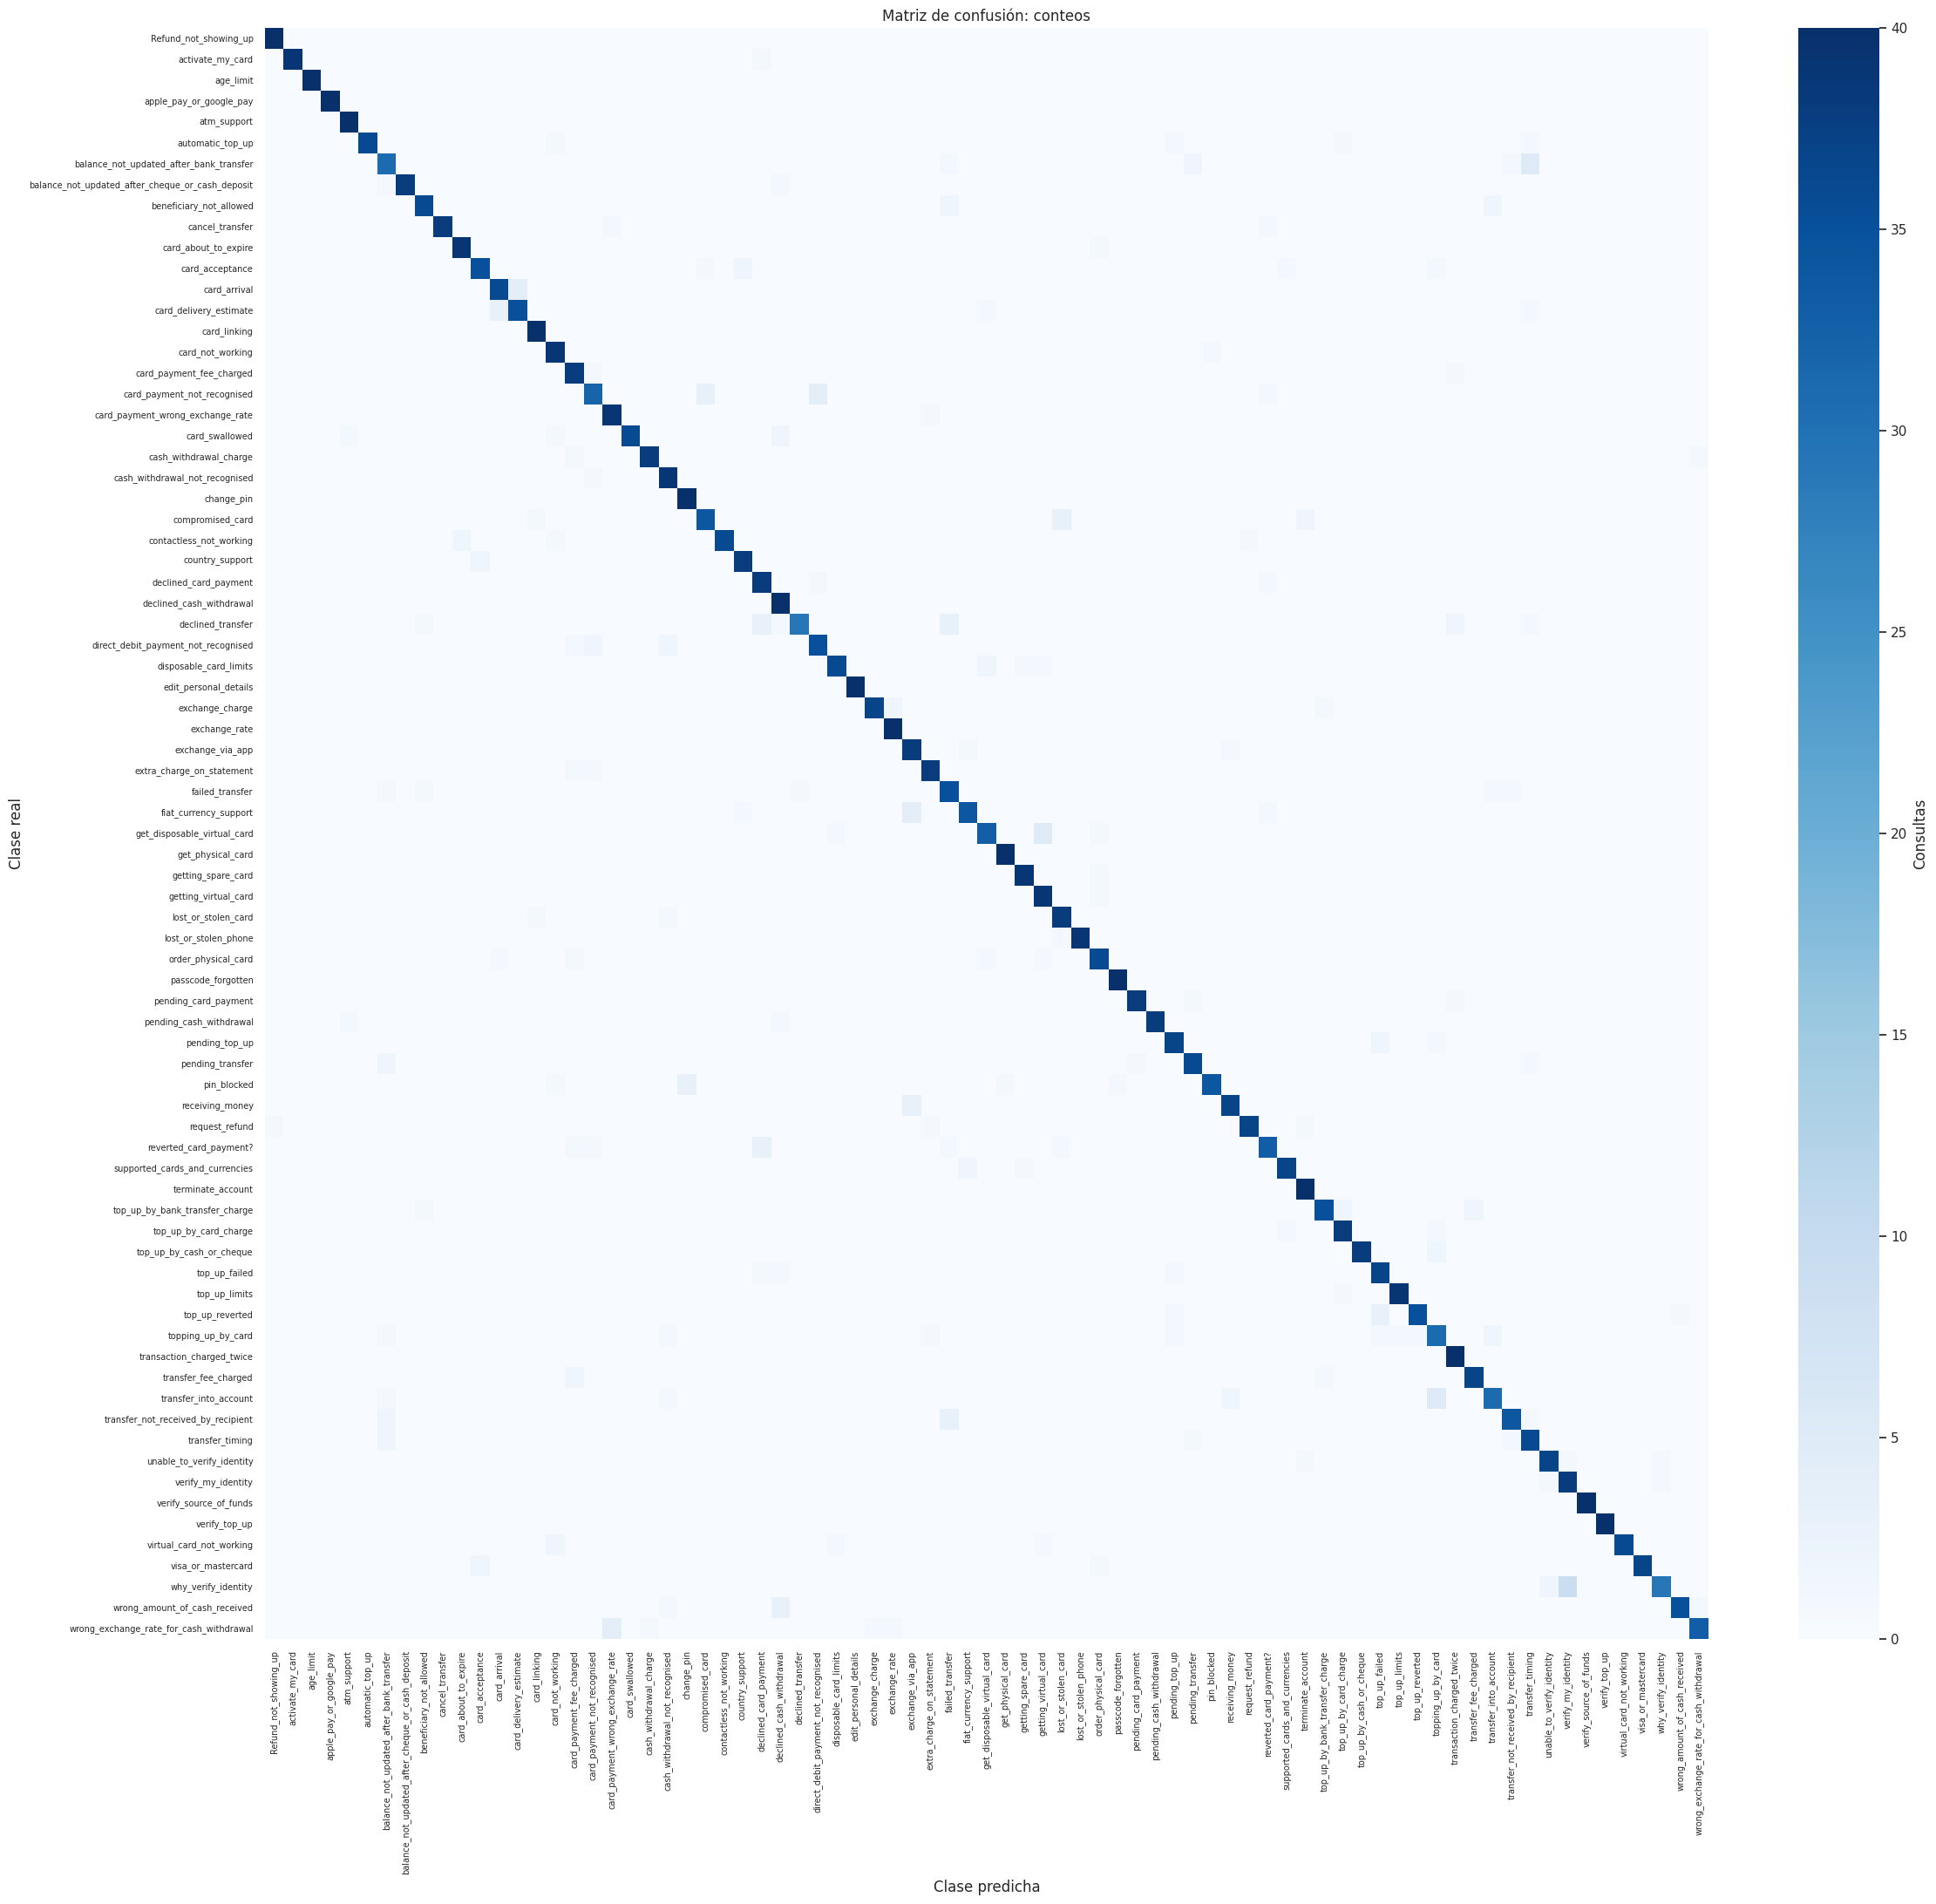

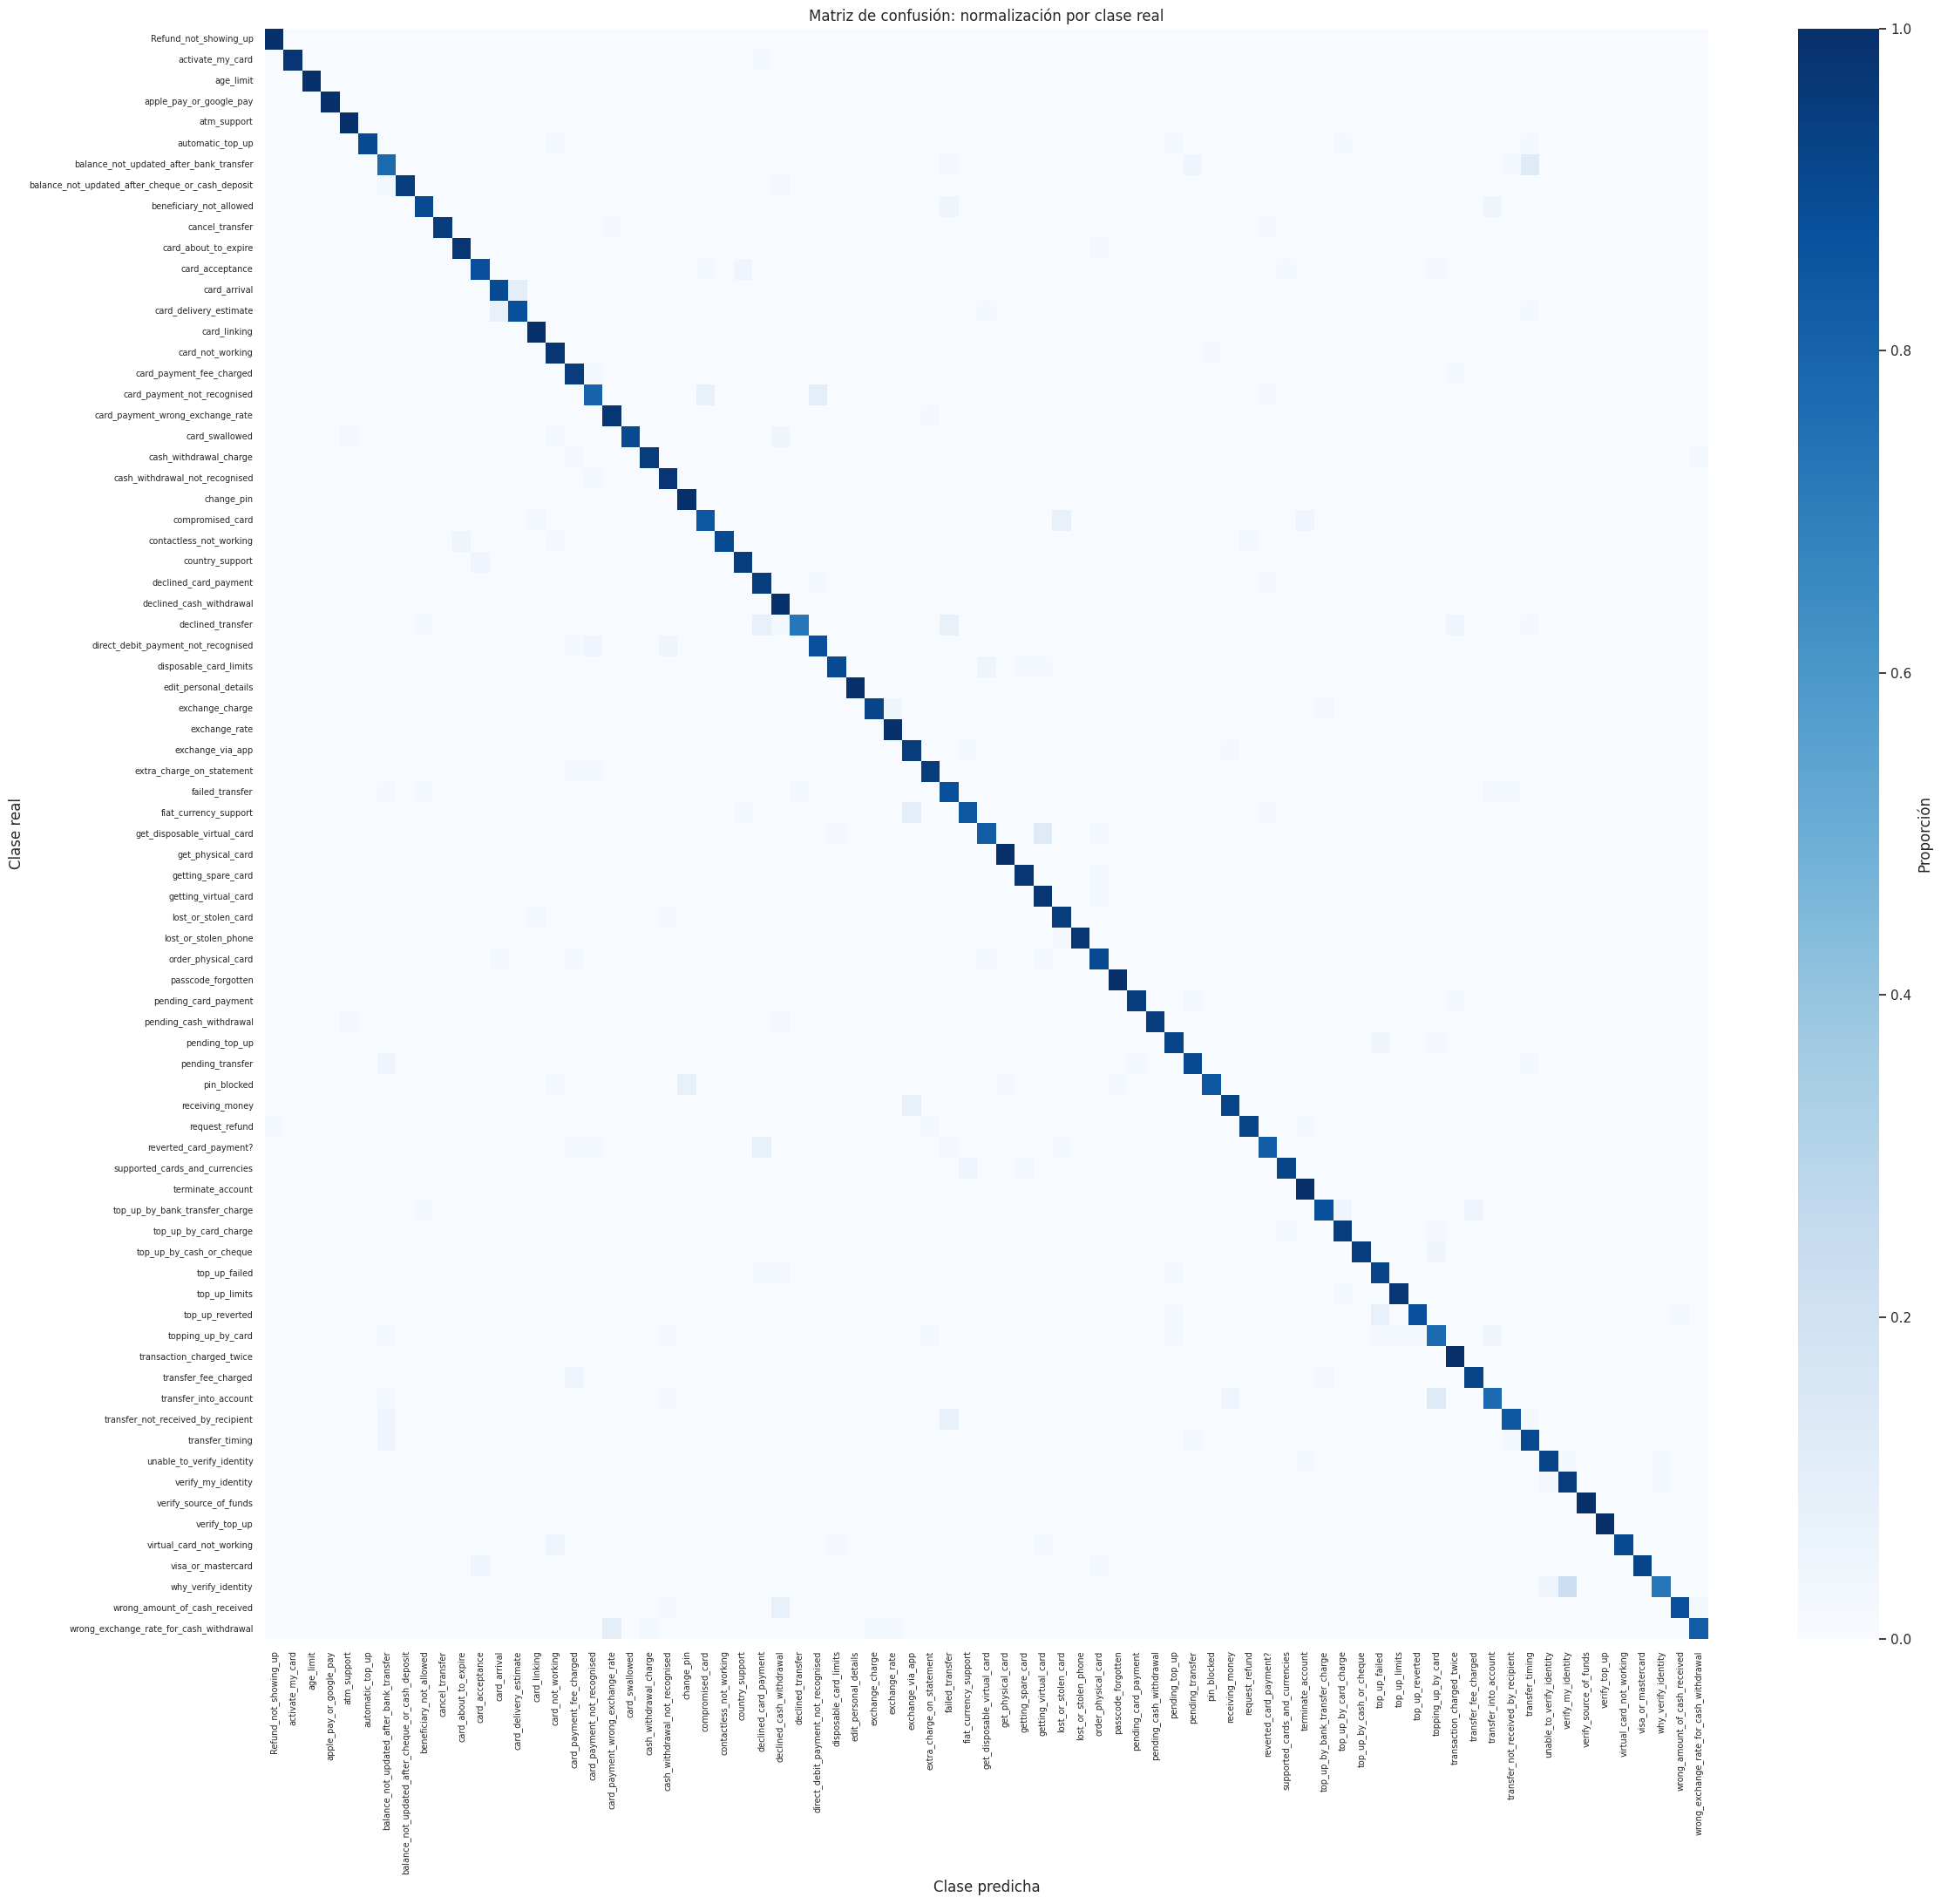

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


def evaluate_predictions(true_labels, predicted_labels, names):
    # Fijar el orden de etiquetas mantiene alineadas las filas/columnas con los nombres de clase.
    label_ids = np.arange(len(names))
    matrix = confusion_matrix(true_labels, predicted_labels, labels=label_ids)
    report = classification_report(
        true_labels, predicted_labels, labels=label_ids,
        target_names=names, output_dict=True, zero_division=0,
    )
    per_class = pd.DataFrame([report[name] for name in names], index=names)
    per_class.index.name = "clase"
    per_class["support"] = per_class["support"].astype(int)
    # La diagonal son aciertos; suma por fila/columna permite separar falsos negativos y positivos.
    per_class["aciertos"] = np.diag(matrix)
    per_class["errores"] = matrix.sum(axis=1) - np.diag(matrix)
    per_class["falsos_positivos"] = matrix.sum(axis=0) - np.diag(matrix)
    return accuracy_score(true_labels, predicted_labels), matrix, report, per_class


# La evaluación conserva logits para calcular probabilidades softmax y etiquetas predichas.
prediction_output = model.predict(test_dataset, verbose=1)
test_logits = prediction_output["logits"]
test_probabilities = tf.nn.softmax(test_logits, axis=-1).numpy()
predicted_labels = test_logits.argmax(axis=1)
assert len(predicted_labels) == len(evaluation_df)
test_accuracy, confusion, metrics_report, per_class_metrics = evaluate_predictions(
    test_labels, predicted_labels, class_names,
)
print(f"Accuracy: {test_accuracy:.4f} ({test_accuracy:.2%})")
print(classification_report(
    test_labels, predicted_labels, labels=np.arange(len(class_names)),
    target_names=class_names, digits=4, zero_division=0,
))
display(pd.DataFrame({
    "macro avg": metrics_report["macro avg"],
    "weighted avg": metrics_report["weighted avg"],
}).T)

confusion_df = pd.DataFrame(confusion, index=class_names, columns=class_names)
normalized_confusion = confusion / np.maximum(confusion.sum(axis=1, keepdims=True), 1)
for title, matrix, colorbar_label in [
    ("Matriz de confusión: conteos", confusion_df, "Consultas"),
    ("Matriz de confusión: normalización por clase real", normalized_confusion, "Proporción"),
]:
    fig, axis = plt.subplots(figsize=(24, 22))
    sns.heatmap(matrix, ax=axis, cmap="Blues", xticklabels=class_names,
                yticklabels=class_names, cbar_kws={"label": colorbar_label})
    axis.set(title=title, xlabel="Clase predicha", ylabel="Clase real")
    axis.tick_params(axis="both", labelsize=7)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

per_class_metrics.to_csv(OUTPUT_DIR / "classification_report.csv")
confusion_df.to_csv(OUTPUT_DIR / "confusion_matrix.csv")

## Siete clases mejor clasificadas y siete con más errores

Las mejores se ordenan por **F1 descendente**, con recall y nombre como desempate. Las problemáticas se ordenan por **número de consultas reales de la clase clasificadas incorrectamente** (falsos negativos), con F1 ascendente y nombre como desempate. Se muestran también falsos positivos: una clase puede recibir muchas consultas ajenas aunque tenga pocos falsos negativos.

En test cada clase tiene 40 consultas, por lo que comparar errores absolutos es equivalente a comparar recall. Los rankings describen esta ejecución y pueden cambiar con la semilla, el entrenamiento y las muestras.

Siete clases mejor clasificadas (F1):


,clase,precision,recall,f1-score,support,aciertos,errores,falsos_positivos
2,age_limit,1.0000,1.0,1.0000,40,40,0,0
3,apple_pay_or_google_pay,1.0000,1.0,1.0000,40,40,0,0
31,edit_personal_details,1.0000,1.0,1.0000,40,40,0,0
70,verify_source_of_funds,1.0000,1.0,1.0000,40,40,0,0
71,verify_top_up,1.0000,1.0,1.0000,40,40,0,0
0,Refund_not_showing_up,0.9756,1.0,0.9877,40,40,0,1
39,get_physical_card,0.9756,1.0,0.9877,40,40,0,1


Siete clases con más errores (falsos negativos):


,clase,precision,recall,f1-score,support,aciertos,errores,falsos_positivos
74,why_verify_identity,0.9355,0.725,0.8169,40,29,11,2
28,declined_transfer,0.9667,0.725,0.8286,40,29,11,1
6,balance_not_updated_after_bank_transfer,0.7561,0.775,0.7654,40,31,9,10
62,topping_up_by_card,0.7561,0.775,0.7654,40,31,9,10
65,transfer_into_account,0.8611,0.775,0.8158,40,31,9,5
17,card_payment_not_recognised,0.8421,0.800,0.8205,40,32,8,6
38,get_disposable_virtual_card,0.8919,0.825,0.8571,40,33,7,4


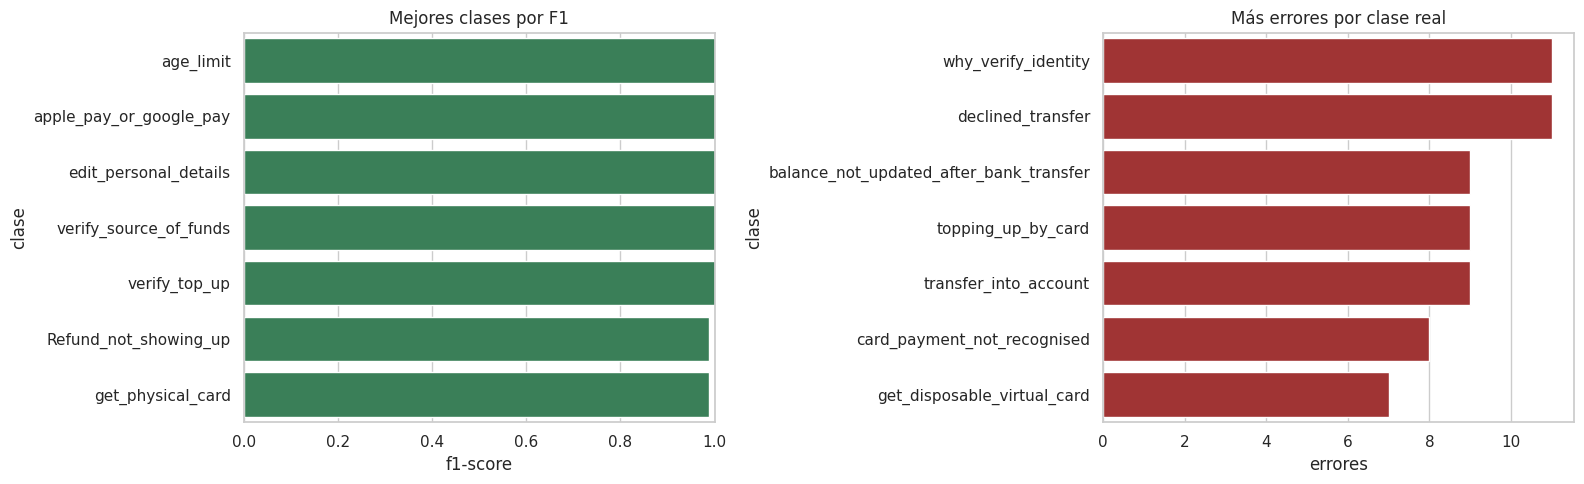

In [17]:
ranking = per_class_metrics.reset_index()
best_seven = ranking.sort_values(
    ["f1-score", "recall", "clase"], ascending=[False, False, True],
).head(7)
worst_seven = ranking.sort_values(
    ["errores", "f1-score", "clase"], ascending=[False, True, True],
).head(7)
print("Siete clases mejor clasificadas (F1):")
display(best_seven.round(4))
print("Siete clases con más errores (falsos negativos):")
display(worst_seven.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=best_seven, x="f1-score", y="clase", color="seagreen", ax=axes[0])
axes[0].set(title="Mejores clases por F1", xlim=(0, 1))
sns.barplot(data=worst_seven, x="errores", y="clase", color="firebrick", ax=axes[1])
axes[1].set_title("Más errores por clase real")
plt.tight_layout()
plt.show()

## Análisis de clases problemáticas

Se inspeccionan las confusiones más frecuentes y hasta tres errores por clase, junto con el número de ejemplos usados para ajustar el modelo. Esto permite evaluar hipótesis:

- **Solapamiento semántico:** intenciones de tarjeta, transferencia, comisiones o estados pendientes pueden compartir vocabulario. Leer el objeto y el estado de cada operación en los errores, no solo el nombre de la clase.
- **Escasez o poca diversidad:** menos ejemplos de entrenamiento pueden limitar la generalización; los pesos de clase no generan nuevas formas de expresar una intención.
- **Ambigüedad y negaciones:** consultas cortas, contracciones o varios problemas en un mismo texto pueden requerir aclaraciones.
- **Truncamiento:** comparar la proporción de textos largos entre errores y aciertos para detectar pérdida potencial de información.
- **Optimización:** revisar las curvas train/validation; divergencia puede sugerir sobreajuste y bajo rendimiento en ambas puede sugerir ajuste insuficiente. Las pérdidas no son directamente comparables si se usan pesos de clase solo en train.

Los ejemplos y asociaciones son evidencia descriptiva, no prueba de causalidad. Las mejoras se seleccionan en validación; después de inspeccionar errores de test, las hipótesis deben confirmarse con otro conjunto independiente.

In [ ]:
# Guardar errores como filas completas permite inspeccionar qué etiquetas se confunden y con qué confianza.
error_analysis = evaluation_df[["text", "category"]].copy()
error_analysis["predicted_category"] = [id2label[int(label)] for label in predicted_labels]
error_analysis["correct"] = test_labels == predicted_labels
error_analysis["max_probability"] = test_probabilities.max(axis=1)
error_analysis["token_length"] = test_token_lengths
error_analysis["truncated"] = test_token_lengths > MAX_LENGTH
classification_errors = error_analysis.loc[~error_analysis["correct"]].copy()
fit_category_support = fit_df["category"].value_counts()

# La confusión es dirigida: clase real A -> predicción B no equivale necesariamente a B -> A.
confusion_pairs = classification_errors.groupby(
    ["category", "predicted_category"],
).size().reset_index(name="errores").sort_values("errores", ascending=False)
print("Principales confusiones dirigidas (clase real -> predicción):")
display(confusion_pairs.head(15))
print("Truncamiento por resultado (media = proporción):")
display(error_analysis.groupby("correct")["truncated"].agg(["count", "mean"]))

diagnostic_rows = []
for category in worst_seven["clase"]:
    category_errors = classification_errors.loc[classification_errors["category"] == category]
    counts = category_errors["predicted_category"].value_counts()
    main_confusion = counts.index[0] if len(counts) else "Sin errores"
    main_confusion_count = int(counts.iloc[0]) if len(counts) else 0
    diagnostic_rows.append({
        "clase": category,
        "train_usado": int(fit_category_support[category]),
        "F1": float(per_class_metrics.loc[category, "f1-score"]),
        "errores": len(category_errors),
        "confusión_principal": main_confusion,
        "errores_en_esa_confusión": main_confusion_count,
        "errores_truncados": int(category_errors["truncated"].sum()),
    })
    notes = []
    if len(counts):
        notes.append(
            f"{main_confusion_count} de {len(category_errors)} errores se dirigen a `{main_confusion}`; "
            "revisar si las consultas distinguen el objeto y el estado de la operación."
        )
    if fit_category_support[category] < fit_category_support.median():
        notes.append("Tiene menos ejemplos de ajuste que la mediana por clase: la cobertura lingüística es una hipótesis a revisar.")
    if category_errors["truncated"].any():
        notes.append("Hay errores en textos truncados; comparar con sus versiones completas antes de atribuirlos al modelo.")
    if not notes:
        notes.append("No hay errores en esta clase; su aparición se debe a empates en el ranking.")
    display(Markdown(f"**{category}**\n\n" + "\n\n".join(notes)))
    display(category_errors.sort_values("max_probability", ascending=False)[
        ["text", "predicted_category", "max_probability", "token_length", "truncated"]
    ].head(3))

diagnostics = pd.DataFrame(diagnostic_rows)
display(diagnostics.round(4))
error_analysis.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)
diagnostics.to_csv(OUTPUT_DIR / "problematic_classes.csv", index=False)

Principales confusiones dirigidas (clase real -> predicción):


,category,predicted_category,errores
152,why_verify_identity,verify_my_identity,9
8,balance_not_updated_after_bank_transfer,transfer_timing,5
73,get_disposable_virtual_card,getting_virtual_card,5
134,transfer_into_account,topping_up_by_card,5
28,card_payment_not_recognised,direct_debit_payment_not_recognised,4
156,wrong_exchange_rate_for_cash_withdrawal,card_payment_wrong_exchange_rate,4
20,card_arrival,card_delivery_estimate,4
70,fiat_currency_support,exchange_via_app,4
94,pin_blocked,change_pin,3
119,top_up_reverted,top_up_failed,3


Truncamiento por resultado (media = proporción):


,count,mean
correct,,
False,241,0.012448
True,2839,0.004931


**why_verify_identity**

9 de 11 errores se dirigen a `verify_my_identity`; revisar si las consultas distinguen el objeto y el estado de la operación.

Tiene menos ejemplos de ajuste que la mediana por clase: la cobertura lingüística es una hipótesis a revisar.

...

**card_payment_not_recognised**

4 de 8 errores se dirigen a `direct_debit_payment_not_recognised`; revisar si las consultas distinguen el objeto y el estado de la operación.

Hay errores en textos truncados; comparar con sus versiones completas antes de atribuirlos al modelo.

,text,predicted_category,max_probability,token_length,truncated
1103,What should I do to get transactions off of my...,compromised_card,0.949849,36,False
1112,Somebody used my card to make a purchase,compromised_card,0.902071,11,False
1096,Can you freeze my account? I just saw there a...,compromised_card,0.854624,31,False


**get_disposable_virtual_card**

5 de 7 errores se dirigen a `getting_virtual_card`; revisar si las consultas distinguen el objeto y el estado de la operación.

Tiene menos ejemplos de ajuste que la mediana por clase: la cobertura lingüística es una hipótesis a revisar.

,text,predicted_category,max_probability,token_length,truncated
2637,how many transactions can i make with a dispos...,disposable_card_limits,0.973548,12,False
2622,how does a virtual card work,getting_virtual_card,0.921508,8,False
2606,I would like a temporary virtual card,getting_virtual_card,0.898205,9,False


,clase,train_usado,F1,errores,confusión_principal,errores_en_esa_confusión,errores_truncados
0,why_verify_identity,103,0.8169,11,verify_my_identity,9,0
1,declined_transfer,113,0.8286,11,declined_card_payment,3,0
2,balance_not_updated_after_bank_transfer,145,0.7654,9,transfer_timing,5,0
3,topping_up_by_card,88,0.7654,9,transfer_into_account,2,0
4,transfer_into_account,96,0.8158,9,topping_up_by_card,5,0
5,card_payment_not_recognised,143,0.8205,8,direct_debit_payment_not_recognised,4,1
6,get_disposable_virtual_card,82,0.8571,7,getting_virtual_card,5,0


## Conclusiones del uso de DistilRoBERTa

La siguiente celda redacta el resumen cuantitativo **después del entrenamiento y la evaluación**, identificando las clases concretas de esta ejecución. No se presume una accuracy ni una lista de clases antes de obtener las predicciones.

DistilRoBERTa permite transferir conocimiento lingüístico y ajustar representaciones contextuales, una ventaja potencial cuando varias intenciones comparten palabras. Sin embargo, para demostrar una mejora se necesita comparar con un baseline bajo el mismo protocolo y repetir el entrenamiento con distintas semillas.

Para clasificar consultas bancarias en línea:

- BANKING77 está en inglés y cubre 77 intenciones; no prueba desempeño en español ni en consultas fuera del dominio.
- Test tiene 40 consultas por clase. Una sola equivocación modifica el recall de una clase en 2.5 puntos porcentuales; no sobreinterpretar diferencias pequeñas.
- Medir latencia, memoria y throughput en el hardware de despliegue. El menor tamaño respecto a RoBERTa no garantiza una latencia aceptable sin medirla.
- Las probabilidades softmax no son confianza calibrada. Calibrar y elegir umbrales en validación para derivar consultas ambiguas o desconocidas a asistencia humana.
- Proteger datos personales y monitorizar cambios de vocabulario, confusiones y rendimiento por clase. Priorizar ejemplos diversos y revisar etiquetas en las clases problemáticas antes de aplicar sobremuestreo.
- Conservar juntos el modelo, el tokenizer, `label2id`, `id2label` y la longitud máxima. El entrenamiento guarda estos artefactos y los reportes en `distilroberta_banking77/`.

La función final devuelve las tres intenciones con mayor probabilidad para consultas nuevas, sin entrenar otra vez. Esta demostración no constituye un servicio de producción.

In [19]:
total_errors = int((test_labels != predicted_labels).sum())
best_names = ", ".join(best_seven["clase"])
worst_names = ", ".join(worst_seven["clase"])
if len(confusion_pairs):
    main_pair = confusion_pairs.iloc[0]
    confusion_summary = (
        f"La confusión dirigida más frecuente fue `{main_pair['category']}` hacia "
        f"`{main_pair['predicted_category']}` ({int(main_pair['errores'])} consultas). "
        "Los ejemplos anteriores permiten revisar el solapamiento semántico, sin demostrar causalidad."
    )
else:
    confusion_summary = "No hubo errores en test en esta ejecución; aun así, se requiere validación externa."

summary = (
    f"### Resumen de esta ejecución\n\n"
    f"El ajuste de DistilRoBERTa seleccionó la época **{best_epoch}** usando la pérdida de validación. "
    f"En las **{len(test_labels):,}** consultas de test obtuvo **accuracy {test_accuracy:.2%}**, "
    f"**F1-macro {metrics_report['macro avg']['f1-score']:.4f}** y "
    f"**F1 ponderado {metrics_report['weighted avg']['f1-score']:.4f}**; "
    f"se clasificaron incorrectamente **{total_errors}** consultas.\n\n"
    f"**Mejores siete por F1:** {best_names}.\n\n"
    f"**Siete con más falsos negativos (incluyendo empates):** {worst_names}.\n\n"
    f"{confusion_summary}\n\n"
    f"Se truncó el **{np.mean(test_token_lengths > MAX_LENGTH):.2%}** de test con "
    f"una longitud máxima de **{MAX_LENGTH}** tokens elegida solo con entrenamiento. "
    "Las métricas describen BANKING77, no consultas reales fuera de esta distribución. "
    "Antes del despliegue, comparar con un baseline, comprobar latencia y calibración, "
    "y validar de manera independiente las mejoras propuestas tras inspeccionar test."
)
display(Markdown(summary))
(OUTPUT_DIR / "conclusions.txt").write_text(summary, encoding="utf-8")


def classify_queries(texts, top_k=3):
    if isinstance(texts, str):
        texts = [texts]
    if not texts or any(not isinstance(text, str) or not text.strip() for text in texts):
        raise ValueError("Proporciona una consulta o una lista de consultas no vacías en inglés.")
    if not isinstance(top_k, int) or not 1 <= top_k <= len(class_names):
        raise ValueError(f"top_k debe estar entre 1 y {len(class_names)}.")
    encoding = dict(tokenizer(
        texts, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors="tf",
    ))
    logits = model(encoding, training=False).logits
    probabilities = tf.nn.softmax(logits, axis=-1).numpy()
    rows = []
    for text, scores in zip(texts, probabilities):
        top_ids = np.argsort(-scores)[:top_k]
        for position, label in enumerate(top_ids, start=1):
            rows.append({
                "consulta": text, "posición": position,
                "intención": model.config.id2label[int(label)],
                "probabilidad_softmax": float(scores[label]),
            })
    return pd.DataFrame(rows)


display(classify_queries(["My card is not working", "How do I activate my card?"]))

### Resumen de esta ejecución

El ajuste de DistilRoBERTa seleccionó la época **5** usando la pérdida de validación. En las **3,080** consultas de test obtuvo **accuracy 92.18%**, **F1-macro 0.9217** y **F1 ponderado 0.9217**; se clasificaron incorrectamente **241** consultas.

**Mejores siete por F1:** age_limit, apple_pay_or_google_pay, edit_personal_details, verify_source_of_funds, verify_top_up, Refund_not_showing_up, get_physical_card.

**Siete con más falsos negativos (incluyendo empates):** why_verify_identity, declined_transfer, balance_not_updated_after_bank_transfer, topping_up_by_card, transfer_into_account, card_payment_not_recognised, get_disposable_virtual_card.

La confusión dirigida más frecuente fue `why_verify_identity` hacia `verify_my_identity` (9 consultas). Los ejemplos anteriores permiten revisar el solapamiento semántico, sin demostrar causalidad.

Se truncó el **0.55%** de test con una longitud máxima de **51** tokens elegida solo con entrenamiento. Las métricas describen BANKING77, no consultas reales fuera de esta distribución. Antes del despliegue, comparar con un baseline, comprobar latencia y calibración, y validar de manera independiente las mejoras propuestas tras inspeccionar test.

,consulta,posición,intención,probabilidad_softmax
0,My card is not working,1,card_not_working,0.969918
1,My card is not working,2,declined_card_payment,0.007042
2,My card is not working,3,lost_or_stolen_card,0.001475
3,How do I activate my card?,1,activate_my_card,0.987610
4,How do I activate my card?,2,card_linking,0.000651
5,How do I activate my card?,3,pin_blocked,0.000567


# 3. Interpretación de errores con Falcon-7B-Instruct

Modelo: [`tiiuae/falcon-7b-instruct`](https://huggingface.co/tiiuae/falcon-7b-instruct). Se genera una **hipótesis textual post hoc**, no una explicación causal de los mecanismos de DistilRoBERTa. El LLM no tiene acceso a sus activaciones ni al proceso que produjo la predicción y puede racionalizar un error.

## Prompt, estructura y parámetros de generación

El prompt separa instrucciones y datos JSON: consulta original, clase predicha y etiqueta real. La etiqueta real se incluye para auditar una clasificación ya evaluada, no para inferencia en producción. Se exige JSON con una razón de un catálogo, un fragmento literal de la consulta y una explicación de hasta **cuatro oraciones completas**. Primero se buscan razones concretas; ambigüedad requiere dos lecturas respaldadas por el texto y la falta de evidencia es la última opción. Se prohíben hechos bancarios inventados y supuestas causas internas.

Configuración conservadora inicial: decodificación **greedy** (`do_sample=False`, temperatura efectiva 0, sin pasar `temperature=0` a la API) y `max_new_tokens=160`. El prompt incluye un ejemplo JSON breve para reducir respuestas narrativas; el límite de tokens no garantiza el formato, por lo que se validan estructura, brevedad y evidencia. Una temperatura baja reduce variación, pero **no elimina alucinaciones**.

Antes de los 20 errores se comparan greedy/160 tokens, muestreo con temperatura 0.2/160 tokens y greedy/192 tokens en tres casos sintéticos independientes de test. La revisión humana comprueba fundamentación, contraste de etiquetas y coherencia; no se declara calibración empírica sin esa revisión.

## Selección reproducible de 20 errores

Se toma una muestra aleatoria sin reemplazo (`random_state=42`) de errores reales de test. Cada consulta debe tener etiqueta real distinta de la predicción; si hay menos de 20, se detiene sin inventar ni repetir muestras. La selección y los resultados se guardan para auditoría.

**Recursos:** En CUDA, Falcon usa cuantización de 8 bits con bitsandbytes, reduciendo el espacio de los pesos a aproximadamente 7 GB, más memoria de ejecución. En Linux, selecciona el kernel **Python (Transformers - PyTorch GPU)**; MPS conserva FP16 y CPU FP32 (~28 GB solo en pesos). Tras instalar o actualizar dependencias, reinicia ese kernel antes de ejecutar esta sección. Guarda primero las predicciones de DistilRoBERTa. Esta sección recupera los errores desde `distilroberta_banking77/test_predictions.csv`, por lo que puede ejecutarse tras cambiar de kernel. Ejecuta un modelo GPU a la vez para liberar memoria; no se eliminan automáticamente modelos ni variables existentes.

In [3]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

FALCON_MODEL_NAME = "tiiuae/falcon-7b-instruct"
FALCON_SEED = 42
FALCON_OUTPUT_DIR = Path("falcon_banking77_analysis")
FALCON_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REASON_DESCRIPTIONS = {
    "semantic_overlap": "Solapamiento semántico entre conceptos de las etiquetas",
    "negation_or_status": "Negación o estado de la operación en la consulta",
    "unsupported_prediction": "La etiqueta predicha no tiene apoyo visible en la consulta",
    "ambiguity": "La consulta admite más de una interpretación",
    "insufficient_evidence": "La consulta no aporta información suficiente",
}
GENERATION_CONFIGS = {"greedy_160": {"do_sample": False, "max_new_tokens": 160}}
SELECTED_CONFIG = "greedy_160"


def select_falcon_errors(predictions, sample_size=20):
    # El muestreo sin reemplazo y la semilla fija hacen reproducible la revisión manual de errores.
    required = {"text", "category", "predicted_category"}
    if not required.issubset(predictions.columns):
        raise ValueError(f"Faltan columnas: {required - set(predictions.columns)}")
    frame = predictions.copy()
    if frame[list(required)].isna().any().any():
        raise ValueError("Las consultas y etiquetas no pueden contener valores nulos.")
    frame["test_row"] = frame.index
    errors = frame.loc[frame["category"] != frame["predicted_category"]]
    # Fallar si faltan casos evita duplicar errores o crear ejemplos sintéticos para el análisis.
    if len(errors) < sample_size:
        raise ValueError(f"Hay {len(errors)} errores; se necesitan {sample_size} errores distintos.")
    return errors.sample(n=sample_size, random_state=FALCON_SEED).reset_index(drop=True)


if "error_analysis" in globals():
    falcon_prediction_frame = error_analysis
else:
    predictions_path = Path("distilroberta_banking77/test_predictions.csv")
    if not predictions_path.exists():
        raise FileNotFoundError("Ejecuta primero la evaluación y el análisis de errores de DistilRoBERTa.")
    falcon_prediction_frame = pd.read_csv(predictions_path)

falcon_samples = select_falcon_errors(falcon_prediction_frame)
assert len(falcon_samples) == 20 and falcon_samples["test_row"].is_unique
falcon_samples.to_csv(FALCON_OUTPUT_DIR / "selected_errors.csv", index=False)
display(falcon_samples[["test_row", "text", "category", "predicted_category"]])


def build_falcon_prompt(query, predicted_label, true_label):
    payload = json.dumps({
        "consulta": str(query),
        "etiqueta_predicha": str(predicted_label),
        "etiqueta_referencia": str(true_label),
    }, ensure_ascii=False)
    reason_keys = ", ".join(REASON_DESCRIPTIONS)
    return (
        "User: Analiza esta clasificación bancaria únicamente como hipótesis textual. "
        "No afirmes conocer el mecanismo interno del clasificador ni inventes hechos del cliente. "
        "Devuelve exactamente un objeto JSON con las claves string reason, evidence y justification. "
        f"reason debe ser una de estas claves: {reason_keys}. Analiza primero la consulta y compara las dos etiquetas. "
        "Prioriza una razón concreta: solapamiento de conceptos, negación o estado, o falta de apoyo textual "
        "para la etiqueta predicha. No elijas ambiguity por defecto: úsala solo si hay palabras concretas "
        "que permitan al menos dos interpretaciones plausibles y explica cuáles son. "
        "La prioridad es proponer una razón y una posible justificación de por qué difieren la etiqueta predicha "
        "y la de referencia. No elijas insufficient_evidence solo porque no encuentres una cita literal: compara "
        "el significado de la consulta y las etiquetas, y formula una hipótesis razonable. Usa insufficient_evidence "
        "solo como última opción, cuando no puedas proponer ninguna explicación plausible. En ese caso, "
        "justification debe limitarse a indicar brevemente la falta de evidencia, sin repetir la consulta ni añadir "
        "una frase larga fija. Puedes inferir una causa probable cuando el texto y las etiquetas la hagan razonable, "
        "pero exprésala como posibilidad (por ejemplo, 'podría deberse a...' o 'es posible que...'), nunca como hecho. "
        "evidence debe ser una cita literal breve si hay una; de lo contrario, usa una cadena vacía, pero conserva "
        "la razón y la hipótesis si el significado del texto permite formularlas. "
        "justification debe ser específica para este caso, sin repetir la consulta: hasta cuatro oraciones breves "
        "que expliquen la razón, comparen las etiquetas y distingan indicios directos de inferencias posibles. "
        "Para ambiguity, describe las dos interpretaciones concretas respaldadas por el texto. "
        "No afirmes causalidad ni determines si la predicción es válida o inválida. "
        "No añadas texto fuera del JSON.\n"
        "Ejemplo: {\"reason\":\"semantic_overlap\",\"evidence\":\"card payment\","
        "\"justification\":\"La frase «card payment» nombra un pago con tarjeta. Ese indicio puede asociarse tanto "
        "con un cobro como con una comisión vinculada al pago, por lo que las etiquetas podrían solaparse. "
        "La consulta no aclara cuál de esos aspectos originó la confusión.\"}\n"
        "Input: " + payload + "\nAssistant: {"
    )


print(build_falcon_prompt(
    falcon_samples.loc[0, "text"],
    falcon_samples.loc[0, "predicted_category"],
    falcon_samples.loc[0, "category"],
))

,test_row,text,category,predicted_category
0,368,How do I unblock my card using the app?,card_not_working,pin_blocked
1,173,Where did this fee come from?,extra_charge_on_statement,card_payment_fee_charged
2,2701,I transferred some money but it is yet to arrive.,balance_not_updated_after_bank_transfer,transfer_not_received_by_recipient
3,2604,how do VR cards work,get_disposable_virtual_card,getting_virtual_card
4,2939,"I will need to get a new card soon, how do I o...",card_about_to_expire,order_physical_card
5,2248,Is it possible for me to get money out in a di...,receiving_money,exchange_via_app
6,2523,My non-physical card will not work,virtual_card_not_working,card_not_working
7,2691,How long does a UK transfer take?,balance_not_updated_after_bank_transfer,transfer_timing
8,246,"There is an incoming payment into my account, ...",fiat_currency_support,reverted_card_payment?
9,1381,How can I create many temporary cards daily?,disposable_card_limits,getting_spare_card


User: Analiza esta clasificación bancaria únicamente como hipótesis textual. No afirmes conocer el mecanismo interno del clasificador ni inventes hechos del cliente. Devuelve exactamente un objeto JSON con las claves string reason, evidence y justification. reason debe ser una de estas claves: semantic_overlap, negation_or_status, unsupported_prediction, ambiguity, insufficient_evidence. Analiza primero la consulta y compara las dos etiquetas. Prioriza una razón concreta: solapamiento de conceptos, negación o estado, o falta de apoyo textual para la etiqueta predicha. No elijas ambiguity por defecto: úsala solo si hay palabras concretas que permitan al menos dos interpretaciones plausibles y explica cuáles son. La prioridad es proponer una razón y una posible justificación de por qué difieren la etiqueta predicha y la de referencia. No elijas insufficient_evidence solo porque no encuentres una cita literal: compara el significado de la consulta y las etiquetas, y formula una hipótesis 

In [4]:
import os
import psutil
import truststore
import torch
from huggingface_hub import HfApi, constants as hub_constants
from transformers import (
    AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, GenerationConfig,
    StoppingCriteria, StoppingCriteriaList, is_bitsandbytes_available, set_seed,
)

truststore.inject_into_ssl()
os.environ["HF_HUB_DISABLE_XET"] = "1"
hub_constants.HF_HUB_DISABLE_XET = True

if torch.cuda.is_available():
    if not is_bitsandbytes_available():
        raise RuntimeError(
            "bitsandbytes no está disponible para este proceso de Transformers. "
            "Selecciona el kernel Python (Transformers - PyTorch GPU), instala las dependencias "
            "y reinicia el kernel antes de continuar."
        )
    falcon_device = "cuda:0"
    falcon_dtype = torch.float16
    available_bytes, _ = torch.cuda.mem_get_info(0)
    required_gib = 10
    falcon_quantization = BitsAndBytesConfig(load_in_8bit=True)
elif torch.backends.mps.is_available():
    falcon_device = "mps"
    falcon_dtype = torch.float16
    available_bytes = psutil.virtual_memory().available
    required_gib = 18
    falcon_quantization = None
else:
    falcon_device = "cpu"
    falcon_dtype = torch.float32
    available_bytes = psutil.virtual_memory().available
    required_gib = 34
    falcon_quantization = None

available_gib = available_bytes / 1024 ** 3
if available_gib < required_gib:
    raise RuntimeError(
        f"Falcon en {falcon_device}: {available_gib:.1f} GiB libres, se recomiendan al menos {required_gib}. "
        "Las 20 muestras ya están guardadas. Cierra el kernel de DistilRoBERTa y ejecuta esta sección "
        "en un kernel nuevo, o usa un equipo con más memoria."
    )

# Para resetear la memoria utilizada en los kernels de vscode: Abre la paleta con Cmd + Shift + P.
# Busca Developer: Reload Window y ejecútalo.

FALCON_REVISION = HfApi().model_info(FALCON_MODEL_NAME).sha
quantization_status = "8-bit" if falcon_quantization is not None else "sin cuantizar"
print(f"Falcon: {falcon_device}, {quantization_status}, {falcon_dtype}, revisión {FALCON_REVISION}")
falcon_tokenizer = AutoTokenizer.from_pretrained(FALCON_MODEL_NAME, revision=FALCON_REVISION)
falcon_tokenizer.pad_token = falcon_tokenizer.eos_token
falcon_model = AutoModelForCausalLM.from_pretrained(
    FALCON_MODEL_NAME, revision=FALCON_REVISION,
    torch_dtype=falcon_dtype, low_cpu_mem_usage=True,
    device_map={"": falcon_device}, trust_remote_code=False,
    quantization_config=falcon_quantization,
    use_safetensors=True, attn_implementation="eager",
)
falcon_model.eval()


def json_response_complete(response):
    # Detener solo al cerrar un objeto JSON parseable; esto valida formato, no la veracidad del texto.
    try:
        return isinstance(json.loads(response.strip()), dict)
    except (json.JSONDecodeError, TypeError):
        return False


class StopAtJsonEnd(StoppingCriteria):
    def __init__(self, tokenizer, prompt_length, response_prefix="{"):
        self.tokenizer = tokenizer
        self.prompt_length = prompt_length
        self.response_prefix = response_prefix

    def __call__(self, input_ids, scores, **kwargs):
        response = self.response_prefix + self.tokenizer.decode(
            input_ids[0, self.prompt_length:], skip_special_tokens=True,
        )
        return json_response_complete(response)


def explain_falcon_case(query, predicted_label, true_label, config_name):
    prompt = build_falcon_prompt(query, predicted_label, true_label)
    encoded = falcon_tokenizer(prompt, return_tensors="pt", truncation=False)
    # Al ser un modelo causal, la salida contiene prompt + continuación; prompt_length separa lo generado.
    prompt_length = encoded["input_ids"].shape[1]
    settings = GENERATION_CONFIGS[config_name].copy()
    context_limit = getattr(falcon_model.config, "max_position_embeddings", 2048)
    
    if prompt_length + settings["max_new_tokens"] > context_limit:
        raise ValueError("El prompt excede el contexto de Falcon; no se trunca la consulta silenciosamente.")
    
    generation_config = GenerationConfig(
        **settings, num_beams=1, repetition_penalty=1.05,
        eos_token_id=falcon_tokenizer.eos_token_id,
        pad_token_id=falcon_tokenizer.pad_token_id,
    )
    set_seed(FALCON_SEED)
    encoded = {name: tensor.to(falcon_device) for name, tensor in encoded.items()}
    
    with torch.inference_mode():
        output = falcon_model.generate(
            **encoded, generation_config=generation_config,
            stopping_criteria=StoppingCriteriaList([StopAtJsonEnd(falcon_tokenizer, prompt_length)]),
        )
    
    # El prefijo "{" ya forma parte de la instrucción de continuación y se recompone al analizar el JSON.
    new_tokens = output[0, prompt_length:]
    raw_response = "{" + falcon_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    parsed, status = parse_falcon_response(raw_response, query)
    
    return {
        "raw_response": raw_response, "validation_status": status,
        "reason": parsed["reason"] if parsed else None,
        "reported_reason": parsed["reported_reason"] if parsed else None,
        "reason_normalized": parsed["reason_normalized"] if parsed else False,
        "evidence": parsed["evidence"] if parsed else None,
        "explanation": parsed["explanation"] if parsed else None,
        "generated_tokens": len(new_tokens),
        "token_limit_reached": len(new_tokens) >= settings["max_new_tokens"],
    }

/home/panchis/.venvs/transformers-torch-gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Falcon: cuda:0, 8-bit, torch.float16, revisión 8782b5c5d8c9290412416618f36a133653e85285


/home/panchis/.venvs/transformers-torch-gpu/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.24s/it]


## Configuración del prompt y la generación

Se usa decodificación greedy (`do_sample=False`), equivalente a temperatura 0: evita variaciones aleatorias al pedir razones comparables. El límite de 160 tokens nuevos deja espacio para el objeto JSON y una justificación más desarrollada, de hasta cuatro oraciones. El prompt prioriza razones textuales concretas; reserva la ambigüedad para cuando el texto respalda dos lecturas y usa la falta de evidencia como último recurso. Estos parámetros priorizan consistencia y detalle, no garantizan veracidad.

In [5]:
def explain_falcon_case(query, predicted_label, true_label, config_name=SELECTED_CONFIG):
    prompt = build_falcon_prompt(query, predicted_label, true_label)
    encoded = falcon_tokenizer(prompt, return_tensors="pt", truncation=False)
    prompt_length = encoded["input_ids"].shape[1]
    settings = GENERATION_CONFIGS[config_name].copy()
    context_limit = getattr(falcon_model.config, "max_position_embeddings", 2048)
    if prompt_length + settings["max_new_tokens"] > context_limit:
        raise ValueError("El prompt excede el contexto de Falcon; no se trunca la consulta silenciosamente.")
    generation_config = GenerationConfig(
        **settings, num_beams=1, repetition_penalty=1.05,
        eos_token_id=falcon_tokenizer.eos_token_id,
        pad_token_id=falcon_tokenizer.pad_token_id,
    )
    set_seed(FALCON_SEED)
    encoded = {name: tensor.to(falcon_device) for name, tensor in encoded.items()}
    with torch.inference_mode():
        output = falcon_model.generate(**encoded, generation_config=generation_config)
    new_tokens = output[0, prompt_length:]
    raw_response = "{" + falcon_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    try:
        parsed = json.loads(raw_response)
    except (json.JSONDecodeError, TypeError):
        parsed = {}
    if not isinstance(parsed, dict):
        parsed = {}
    reason = parsed.get("reason")
    if not isinstance(reason, str) or reason not in REASON_DESCRIPTIONS:
        reason = "insufficient_evidence"
    evidence = parsed.get("evidence")
    if not isinstance(evidence, str):
        evidence = ""
    evidence = evidence.strip()
    if not evidence or evidence not in str(query):
        evidence = ""
    justification = parsed.get("justification")
    if not isinstance(justification, str) or not justification.strip():
        reason = "insufficient_evidence"
        justification = "Evidencia insuficiente para determinar una causa concreta."
    else:
        justification = justification.strip()
    return {
        "reason": reason,
        "evidence": evidence,
        "justification": justification,
        "raw_response": raw_response,
        "generated_tokens": len(new_tokens),
    }


print(f"Configuración seleccionada: {SELECTED_CONFIG}; máximo {GENERATION_CONFIGS[SELECTED_CONFIG]['max_new_tokens']} tokens nuevos.")

Configuración seleccionada: greedy_160; máximo 160 tokens nuevos.


## Justificaciones de las 20 clasificaciones incorrectas

Se genera una respuesta por cada error seleccionado. Para cada consulta se guardan la etiqueta real, la predicha, la razón sugerida por Falcon, una posible cita textual y una justificación específica de hasta cuatro oraciones. La prioridad es proponer por qué difieren las etiquetas y una justificación posible; se permiten inferencias razonables si se expresan como posibilidades, aunque no haya una cita literal. La ambigüedad requiere dos interpretaciones concretas; `insufficient_evidence` solo se usa como último recurso si no hay una explicación plausible. La respuesta original también se conserva para revisarla.

In [6]:
results = []
# La predicción y la etiqueta real se envían junto con el texto para analizar por qué pudo confundirse.
for position, sample in enumerate(falcon_samples.to_dict(orient="records"), start=1):
    response = explain_falcon_case(
        sample["text"], sample["predicted_category"], sample["category"], SELECTED_CONFIG,
    )
    # Conservar la consulta y sus etiquetas junto a la explicación facilita revisar cada caso después.
    results.append({**sample, "generation_config": SELECTED_CONFIG, **response})
    current_results = pd.DataFrame(results)
    # Actualizar ambos archivos en cada vuelta para no perder los casos completados si ocurre un error.
    current_results.to_csv(FALCON_OUTPUT_DIR / "explanations.csv", index=False)
    (FALCON_OUTPUT_DIR / "explanations.json").write_text(
        json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8",
    )
    print(f"Caso {position}/20 generado.")

falcon_results = pd.DataFrame(results)
# Estos datos identifican el modelo y la configuración usados; sirven para interpretar y repetir la generación.
(FALCON_OUTPUT_DIR / "generation_metadata.json").write_text(json.dumps({
    "model": FALCON_MODEL_NAME,
    "seed": FALCON_SEED,
    "generation_config": GENERATION_CONFIGS[SELECTED_CONFIG],
    "decoding": "greedy; temperatura efectiva 0",
}, ensure_ascii=False, indent=2), encoding="utf-8")
# Mostrar etiquetas, explicación y cita juntas para facilitar la revisión humana de cada predicción.
with pd.option_context("display.max_colwidth", None, "display.max_rows", 25):
    display(falcon_results[[
        "test_row", "text", "category", "predicted_category", "reason",
        "evidence", "justification",
    ]])

Caso 1/20 generado.
Caso 2/20 generado.
Caso 3/20 generado.
Caso 4/20 generado.
Caso 5/20 generado.
Caso 6/20 generado.
Caso 7/20 generado.
Caso 8/20 generado.
Caso 9/20 generado.
Caso 10/20 generado.
Caso 11/20 generado.
Caso 12/20 generado.
Caso 13/20 generado.
Caso 14/20 generado.
Caso 15/20 generado.
Caso 16/20 generado.
Caso 17/20 generado.
Caso 18/20 generado.
Caso 19/20 generado.
Caso 20/20 generado.


,test_row,text,category,predicted_category,reason,evidence,justification
0,368,How do I unblock my card using the app?,card_not_working,pin_blocked,semantic_overlap,,"La frase «card payment» nombra un pago con tarjeta. Ese indicio puede asociarse tanto con un cobro como con una comisión vinculada al pago, por lo que las etiquetas podrían solaparse. La consulta no aclara cuál de esos aspectos originó la confusión."
1,173,Where did this fee come from?,extra_charge_on_statement,card_payment_fee_charged,insufficient_evidence,,Evidencia insuficiente para determinar una causa concreta.
2,2701,I transferred some money but it is yet to arrive.,balance_not_updated_after_bank_transfer,transfer_not_received_by_recipient,insufficient_evidence,,Evidencia insuficiente para determinar una causa concreta.
3,2604,how do VR cards work,get_disposable_virtual_card,getting_virtual_card,semantic_overlap,,"La frase «card payment» nombra un pago con tarjeta. Ese indicio puede asociarse tanto con un cobro como con una comisión vinculada al pago, por lo que las etiquetas podrían solaparse. La consulta no aclara cuál de esos aspectos originó la confusión."
4,2939,"I will need to get a new card soon, how do I order?",card_about_to_expire,order_physical_card,insufficient_evidence,,Evidencia insuficiente para determinar una causa concreta.
5,2248,Is it possible for me to get money out in a different currency?,receiving_money,exchange_via_app,insufficient_evidence,,Evidencia insuficiente para determinar una causa concreta.
6,2523,My non-physical card will not work,virtual_card_not_working,card_not_working,insufficient_evidence,,Evidencia insuficiente para determinar una causa concreta.
7,2691,How long does a UK transfer take?,balance_not_updated_after_bank_transfer,transfer_timing,insufficient_evidence,,Evidencia insuficiente para determinar una causa concreta.
8,246,"There is an incoming payment into my account, but it is deactivated. Will they still be processed?",fiat_currency_support,reverted_card_payment?,insufficient_evidence,,Evidencia insuficiente para determinar una causa concreta.
9,1381,How can I create many temporary cards daily?,disposable_card_limits,getting_spare_card,semantic_overlap,,"La frase «card payment» nombra un pago con tarjeta. Ese indicio puede asociarse tanto con un cobro como con una comisión vinculada al pago, por lo que las etiquetas podrían solaparse. La consulta no aclara cuál de esos aspectos originó la confusión."


## Análisis y listado de las razones proporcionadas

La tabla muestra las veinte razones y justificaciones sugeridas por el LLM junto con la evidencia textual que citó. El recuento agrupa las razones para facilitar la lectura; describe únicamente esta muestra y las categorías indicadas en el prompt.

In [8]:
# Traducir los códigos previstos en el prompt; si aparece uno nuevo, conservar su texto original.
REASON_LABELS_ES = {
    "semantic_overlap": "Solapamiento semántico",
    "negation_or_status": "Negación o estado de la operación",
    "ambiguity": "Ambigüedad de la consulta",
    "insufficient_evidence": "Información insuficiente",
    "unsupported_prediction": "Predicción sin apoyo textual",
}
falcon_results["razón"] = falcon_results["reason"].map(REASON_LABELS_ES).fillna(falcon_results["reason"])
# Excluir razones vacías del recuento; no elimina esas filas del listado detallado de abajo.
falcon_reason_counts = (
    falcon_results.loc[falcon_results["reason"].astype(str).str.strip().ne(""), "razón"]
    .value_counts().rename_axis("razón").reset_index(name="casos")
)
print(f"Muestras con explicación solicitada: {len(falcon_results)}")
display(falcon_reason_counts)

# Mostrar los campos necesarios para comprobar si la explicación coincide con el texto y las etiquetas.
with pd.option_context("display.max_colwidth", None, "display.max_rows", 25):
    display(falcon_results[[
        "test_row", "text", "category", "predicted_category", "razón",
        "evidence", "justification",
    ]])

# Guardar por separado el recuento agregado y el detalle de cada explicación para revisarlos después.
falcon_reason_counts.to_csv(FALCON_OUTPUT_DIR / "reason_frequencies.csv", index=False)
falcon_results.to_csv(FALCON_OUTPUT_DIR / "explanations_reviewed.csv", index=False)

Muestras con explicación solicitada: 20


,razón,casos
0,Información insuficiente,17
1,Solapamiento semántico,3


,test_row,text,category,predicted_category,razón,evidence,justification
0,368,How do I unblock my card using the app?,card_not_working,pin_blocked,Solapamiento semántico,,"La frase «card payment» nombra un pago con tarjeta. Ese indicio puede asociarse tanto con un cobro como con una comisión vinculada al pago, por lo que las etiquetas podrían solaparse. La consulta no aclara cuál de esos aspectos originó la confusión."
1,173,Where did this fee come from?,extra_charge_on_statement,card_payment_fee_charged,Información insuficiente,,Evidencia insuficiente para determinar una causa concreta.
2,2701,I transferred some money but it is yet to arrive.,balance_not_updated_after_bank_transfer,transfer_not_received_by_recipient,Información insuficiente,,Evidencia insuficiente para determinar una causa concreta.
3,2604,how do VR cards work,get_disposable_virtual_card,getting_virtual_card,Solapamiento semántico,,"La frase «card payment» nombra un pago con tarjeta. Ese indicio puede asociarse tanto con un cobro como con una comisión vinculada al pago, por lo que las etiquetas podrían solaparse. La consulta no aclara cuál de esos aspectos originó la confusión."
4,2939,"I will need to get a new card soon, how do I order?",card_about_to_expire,order_physical_card,Información insuficiente,,Evidencia insuficiente para determinar una causa concreta.
5,2248,Is it possible for me to get money out in a different currency?,receiving_money,exchange_via_app,Información insuficiente,,Evidencia insuficiente para determinar una causa concreta.
6,2523,My non-physical card will not work,virtual_card_not_working,card_not_working,Información insuficiente,,Evidencia insuficiente para determinar una causa concreta.
7,2691,How long does a UK transfer take?,balance_not_updated_after_bank_transfer,transfer_timing,Información insuficiente,,Evidencia insuficiente para determinar una causa concreta.
8,246,"There is an incoming payment into my account, but it is deactivated. Will they still be processed?",fiat_currency_support,reverted_card_payment?,Información insuficiente,,Evidencia insuficiente para determinar una causa concreta.
9,1381,How can I create many temporary cards daily?,disposable_card_limits,getting_spare_card,Solapamiento semántico,,"La frase «card payment» nombra un pago con tarjeta. Ese indicio puede asociarse tanto con un cobro como con una comisión vinculada al pago, por lo que las etiquetas podrían solaparse. La consulta no aclara cuál de esos aspectos originó la confusión."


## Conclusiones

DistilRoBERTa obtuvo **92.14% de accuracy y F1-macro** en las 3,080 consultas de prueba; aun así, clasificó mal **242**. El resultado es sólido para este conjunto, pero no significa que el modelo vaya a acertar igual de bien con consultas reales diferentes.

Los errores más visibles ocurren entre categorías con significados cercanos. Por ejemplo, `why_verify_identity` se confundió con `verify_my_identity` en 10 casos. Esto sugiere revisar primero esos ejemplos y sus etiquetas; no demuestra por sí solo por qué el modelo se equivocó.

Falcon se usó para proponer explicaciones de 20 errores. Puede ayudar a ordenar posibles motivos y citar palabras de la consulta, pero sus respuestas son hipótesis: no muestran cómo razonó DistilRoBERTa ni verifican la causa del error. Además, 20 casos no bastan para sacar conclusiones sobre todo el conjunto.

Para comparar mejoras, usar validación durante los experimentos y dejar un conjunto de prueba nuevo sin tocar para la evaluación final.

In [9]:
# Convertir los conteos a texto para incluirlos en el resumen que se muestra al final.
reason_listing = "; ".join(
    f"{row['razón']}: {int(row['casos'])}"
    for row in falcon_reason_counts.to_dict(orient="records")
) or "No se generó una razón estructurada"

# Reunir el tamaño de la muestra, el modelo y los parámetros junto con las razones observadas.
falcon_summary = (
    "### Resumen de esta ejecución\n\n"
    f"Se solicitaron razones, citas y justificaciones posibles para **{len(falcon_results)}** errores usando "
    f"**{FALCON_MODEL_NAME}**. La generación fue greedy (temperatura efectiva 0), con máximo de "
    f"**{GENERATION_CONFIGS[SELECTED_CONFIG]['max_new_tokens']}** tokens y hasta cuatro oraciones de justificación.\n\n"
    f"**Razones sugeridas:** {reason_listing}.\n\n"
    "Son interpretaciones posibles basadas en el texto, no causas verificadas del comportamiento del clasificador."
)
display(Markdown(falcon_summary))

# Guardar exactamente el texto mostrado para consultarlo o compartirlo fuera del notebook.
(FALCON_OUTPUT_DIR / "conclusions.txt").write_text(falcon_summary, encoding="utf-8")

### Resumen de esta ejecución

Se solicitaron razones, citas y justificaciones posibles para **20** errores usando **tiiuae/falcon-7b-instruct**. La generación fue greedy (temperatura efectiva 0), con máximo de **160** tokens y hasta cuatro oraciones de justificación.

**Razones sugeridas:** Información insuficiente: 17; Solapamiento semántico: 3.

Son interpretaciones posibles basadas en el texto, no causas verificadas del comportamiento del clasificador.

460

# 4. Mejoras técnicas propuestas

El modelo ya ofrece un buen resultado, así que conviene probar cambios pequeños y medir si realmente ayudan. El test actual se utilizó para revisar errores; para comparar nuevas versiones, usar validación y reservar un test nuevo e independiente para la comprobación final.

## Propuestas en orden de prioridad

1. **Revisar los errores más repetidos.** Empezar por `why_verify_identity` → `verify_my_identity` (10 casos), `balance_not_updated_after_bank_transfer` → `transfer_timing` (5) y `get_disposable_virtual_card` → `getting_virtual_card` (5). Leer las consultas y comprobar si las etiquetas son correctas o si las categorías necesitan ejemplos más claros. Es la primera opción porque ayuda a entender el problema antes de cambiar el modelo.

2. **Comprobar si los pesos de clase ayudan.** Entrenar una versión sin pesos y compararla con la configuración actual, manteniendo los mismos datos y la misma validación. Comparar F1-macro (promedia el resultado de las clases por igual) y el recall de cada clase. Conservar los pesos solo si el resultado mejora sin perjudicar mucho a otras clases.

3. **Probar ejemplos de entrenamiento adicionales.** Crear unas pocas paráfrasis para las clases con pocos ejemplos o con confusiones frecuentes. Revisar cada frase a mano para asegurar que conserva el mismo significado, sobre todo la negación y el estado de una transferencia o tarjeta. Añadirlas solo al entrenamiento, nunca al test, y medir el resultado frente a la versión original.

4. **No aumentar todavía la longitud máxima por defecto.** Solo se truncó el 0.55% de las consultas de test. Revisar primero si esos casos explican errores; si no, mantener el límite actual. Si se prueba otro límite, elegirlo con validación y comparar también el tiempo de ejecución.

Estas pruebas no garantizan una mejora. Hacerlas de una en una permite identificar cuál aporta valor y evita complicar el sistema sin necesidad.